# Informer + WeightWatcher: Encoder Layer Spectral Analysis

This notebook demonstrates how to extract encoder layer weights from the Informer (2020) model and analyze their singular value spectra using the WeightWatcher framework.

In [1]:
import torch
import weightwatcher as ww
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

PyTorch is available but CUDA is not. Defaulting to SciPy for SVD
Import error , reetting to svd accurate methods


In [3]:
# Preview Informer encoder structure
INFORMER_PATH = Path("../Informer2020")
sys.path.insert(0, str(INFORMER_PATH))
from models.model import Informer

model = Informer(
    enc_in=7, dec_in=7, c_out=7,
    seq_len=96, label_len=48, out_len=24,
    factor=5, d_model=512, n_heads=8, e_layers=2, d_layers=1, d_ff=2048,
    dropout=0.05, attn='prob', embed='fixed', freq='h', activation='gelu',
    output_attention=False, distil=True, mix=True, device='cpu'
)
print(model.encoder)

Encoder(
  (attn_layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (attention): AttentionLayer(
        (inner_attention): ProbAttention(
          (dropout): Dropout(p=0.05, inplace=False)
        )
        (query_projection): Linear(in_features=512, out_features=512, bias=True)
        (key_projection): Linear(in_features=512, out_features=512, bias=True)
        (value_projection): Linear(in_features=512, out_features=512, bias=True)
        (out_projection): Linear(in_features=512, out_features=512, bias=True)
      )
      (conv1): Conv1d(512, 2048, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(2048, 512, kernel_size=(1,), stride=(1,))
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.05, inplace=False)
    )
  )
  (conv_layers): ModuleList(
    (0): ConvLayer(
      (downConv): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=

SMALL N PL FIT


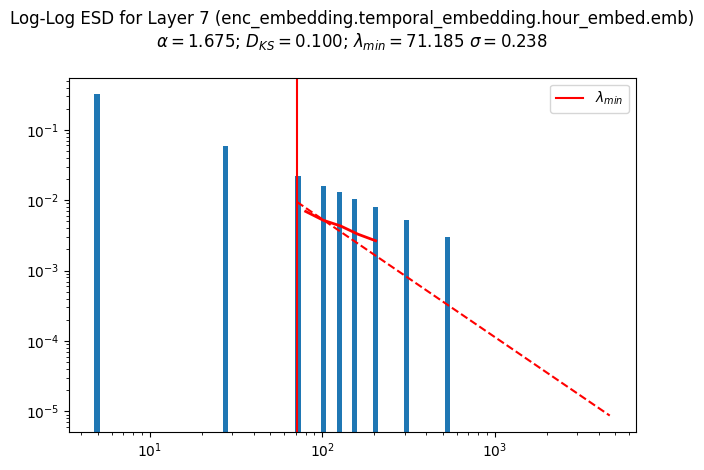

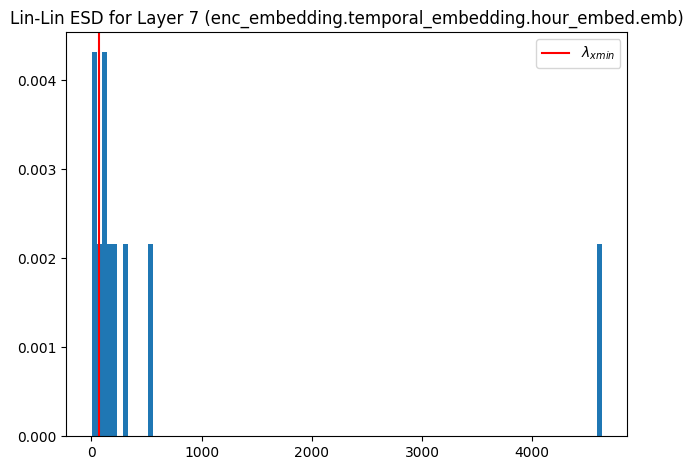

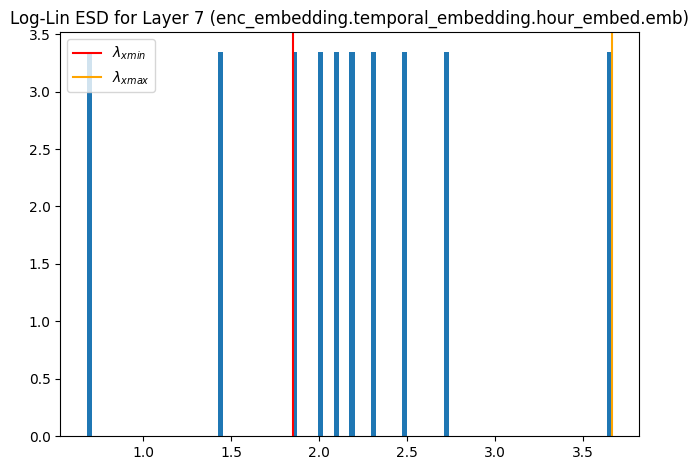

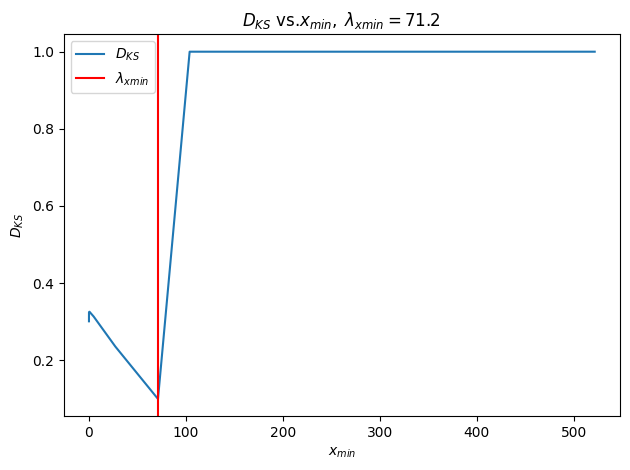

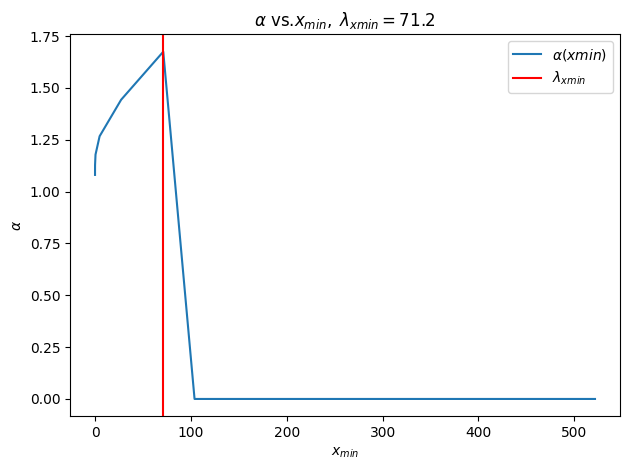

SMALL N PL FIT


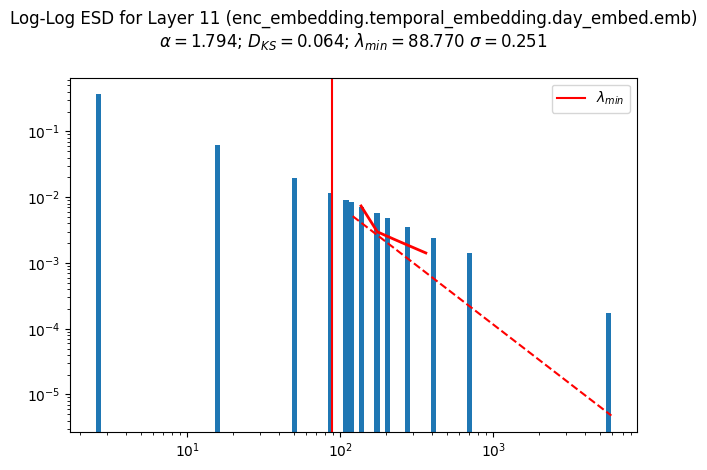

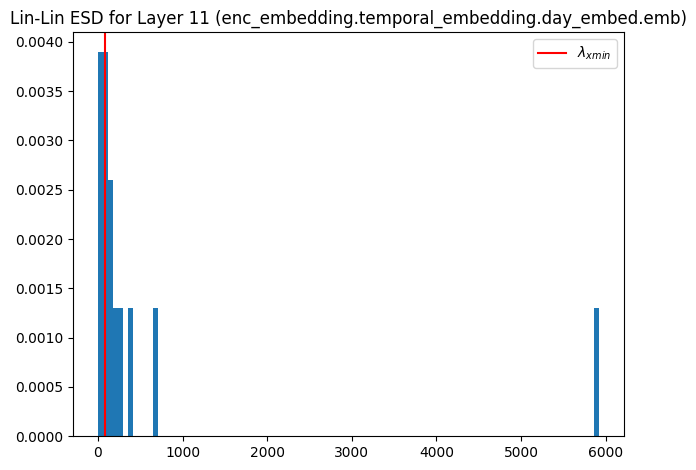

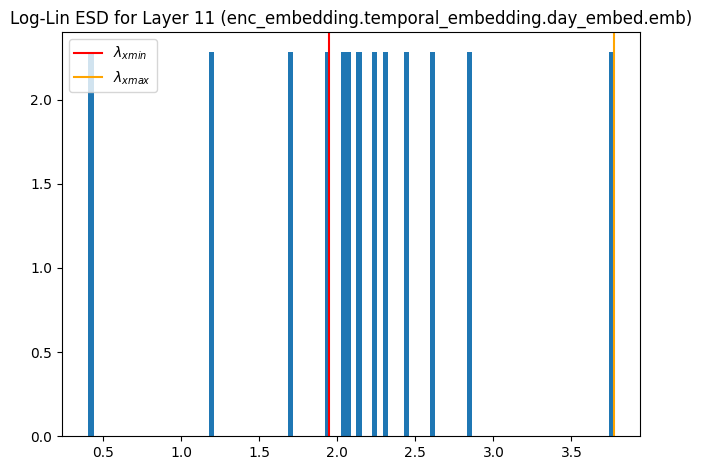

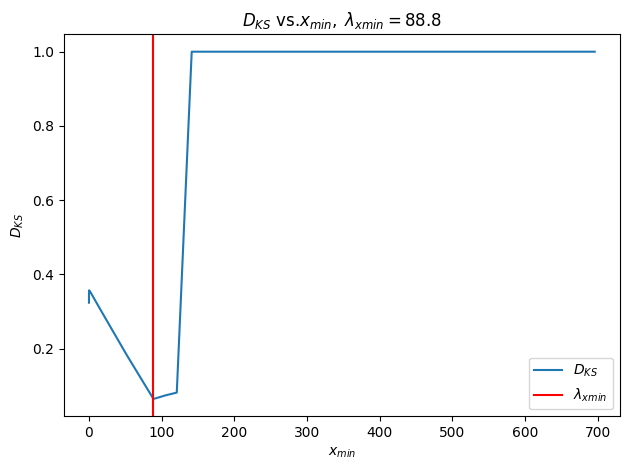

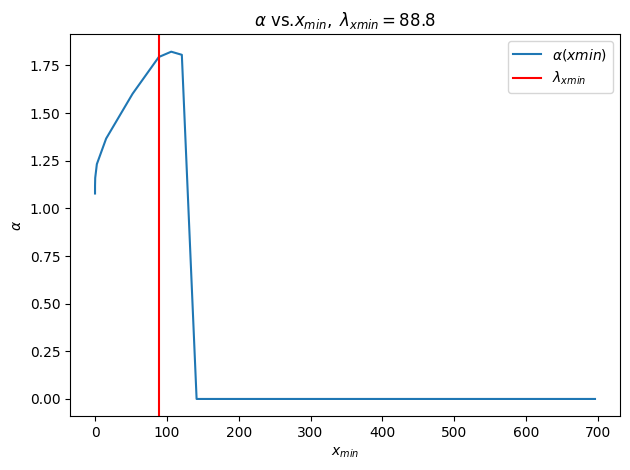

SMALL N PL FIT


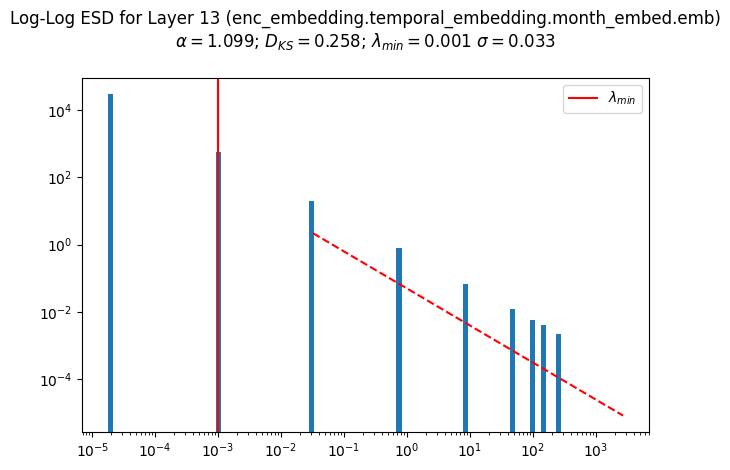

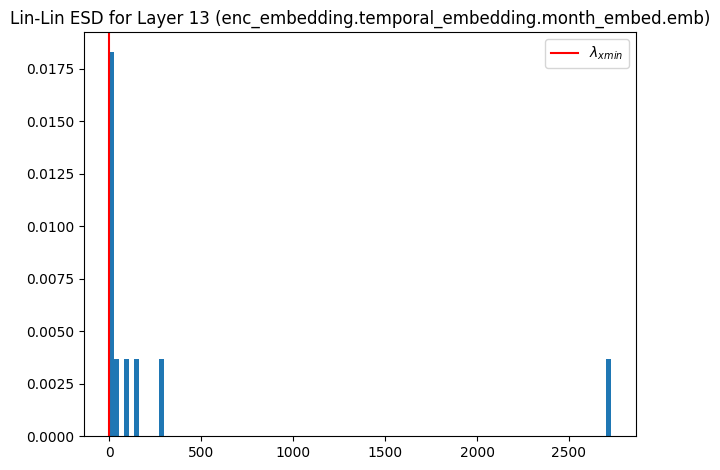

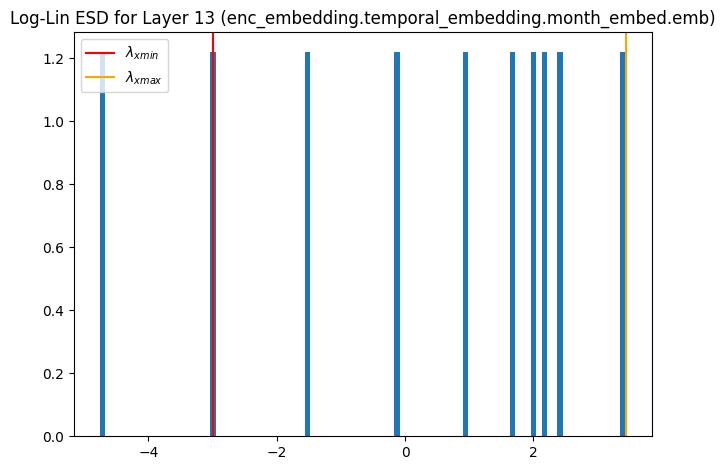

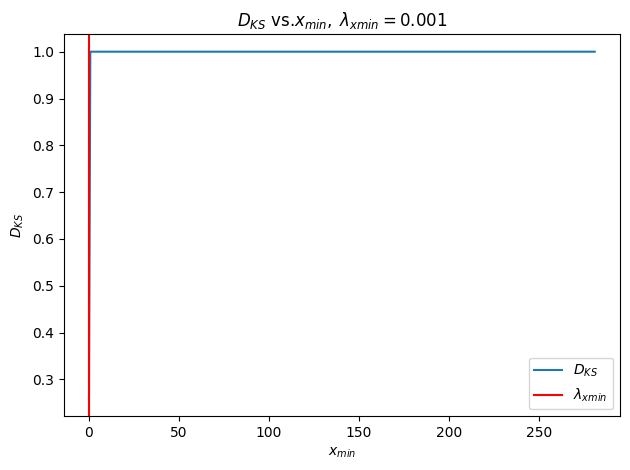

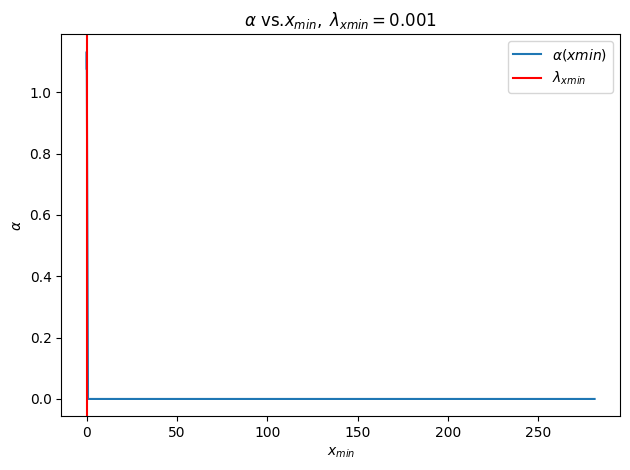

SMALL N PL FIT


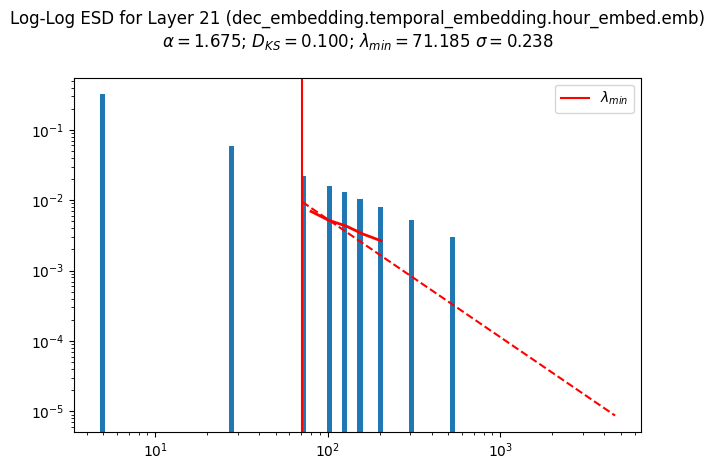

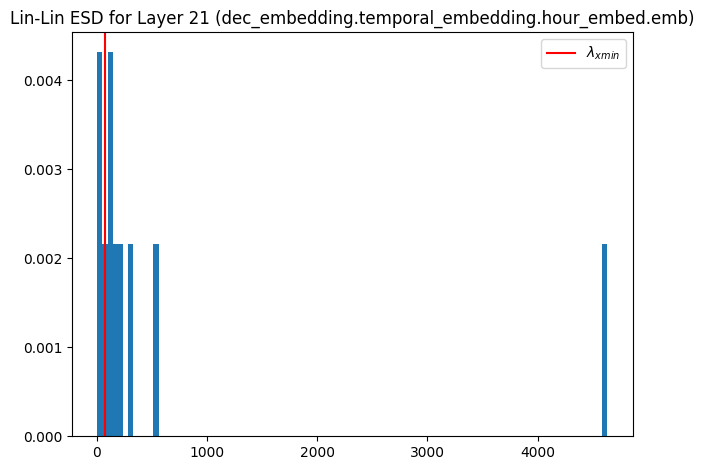

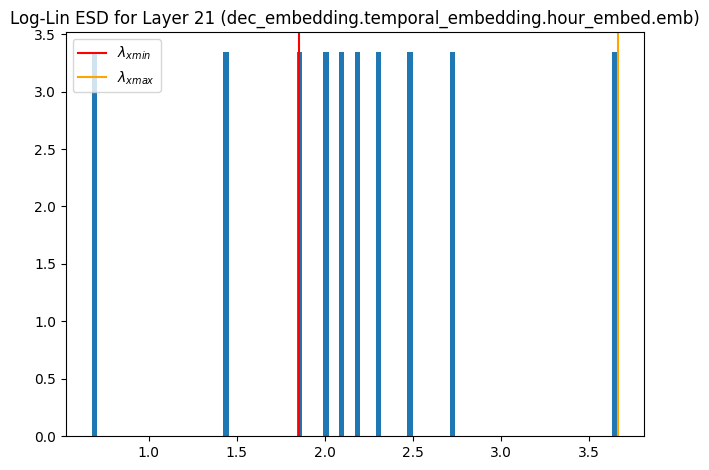

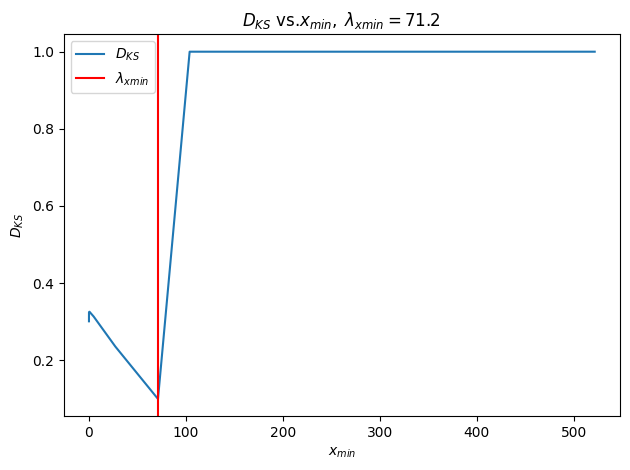

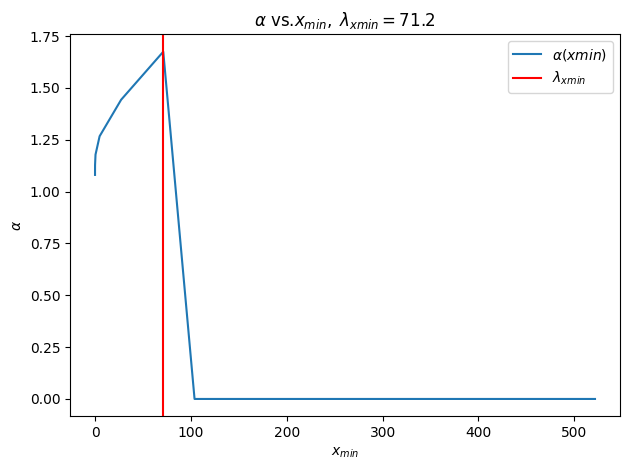

SMALL N PL FIT


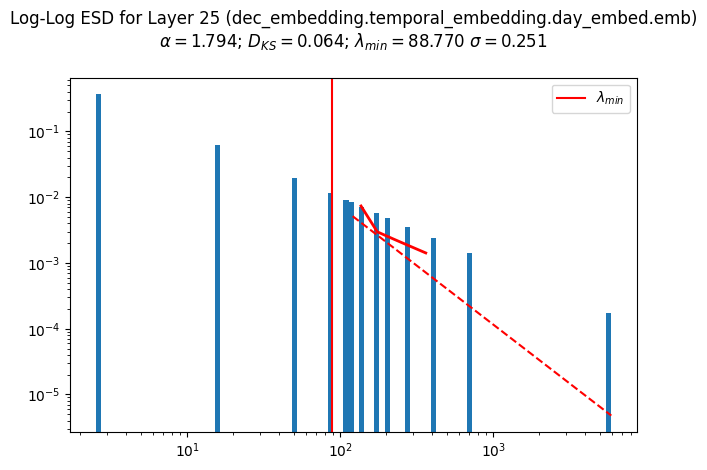

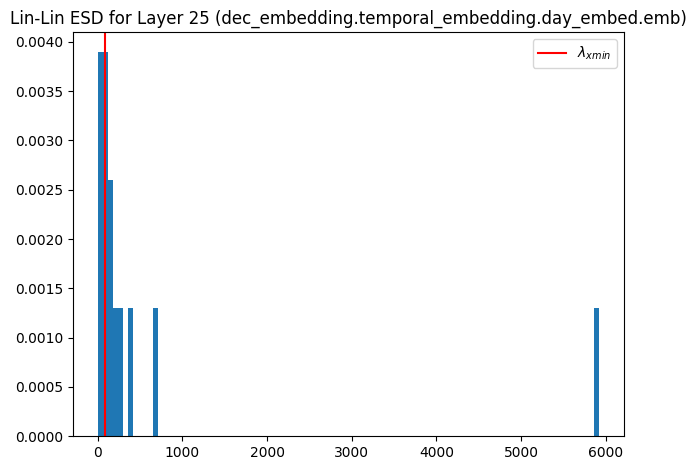

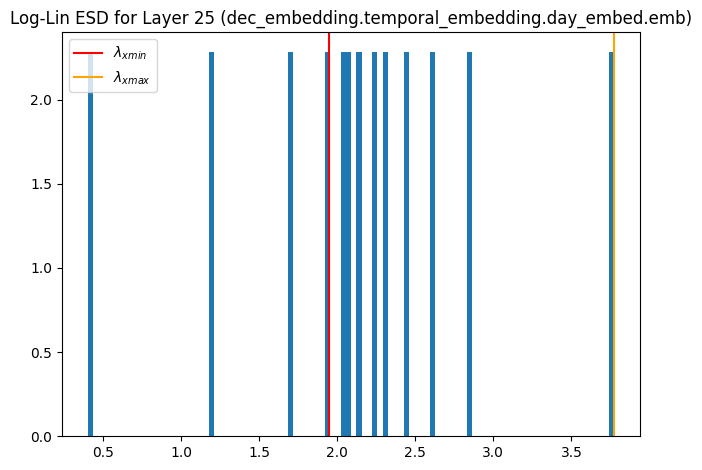

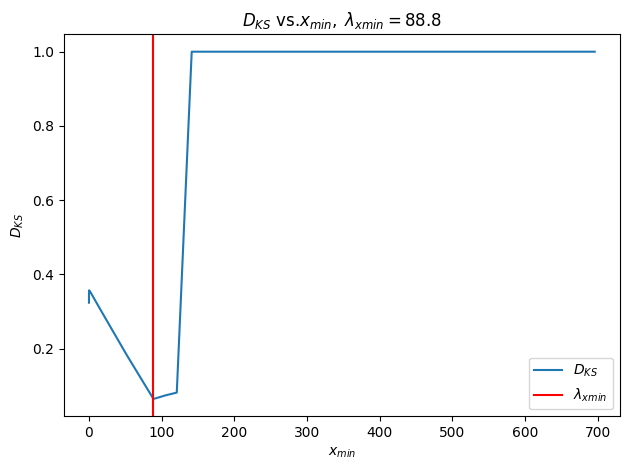

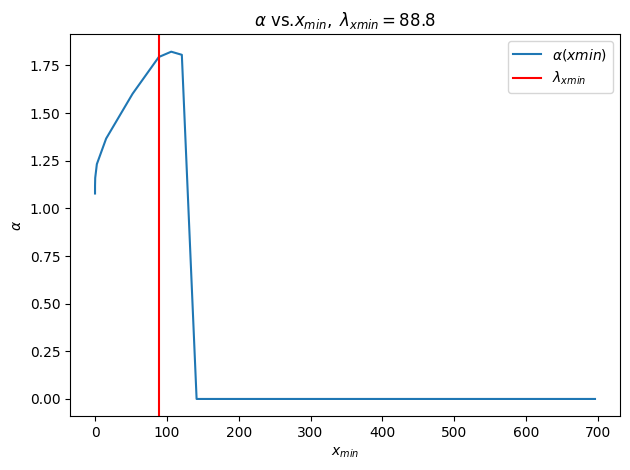

SMALL N PL FIT


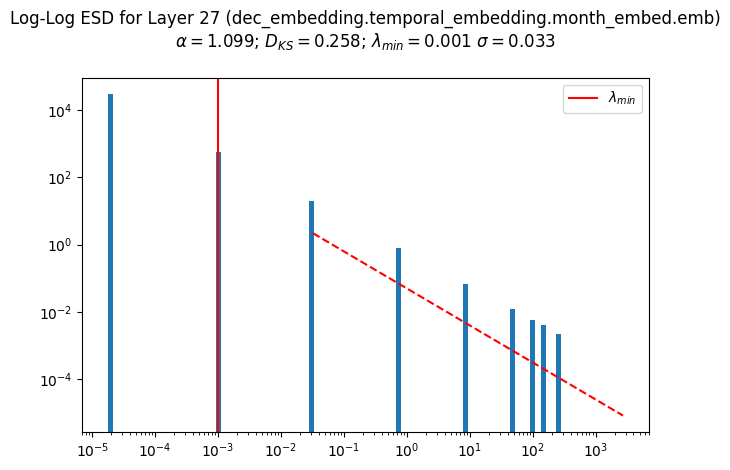

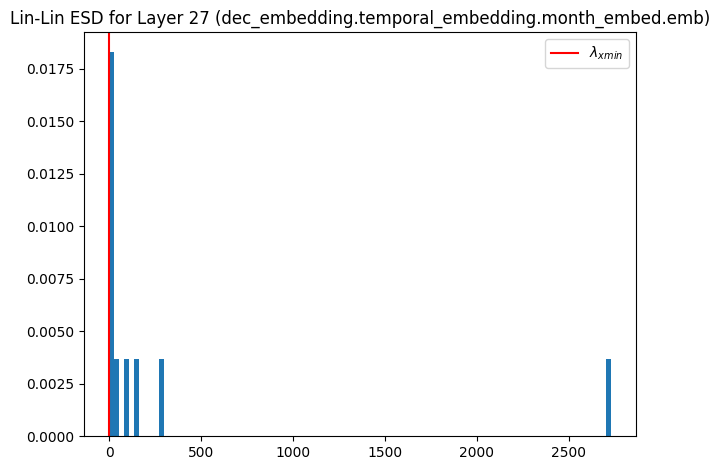

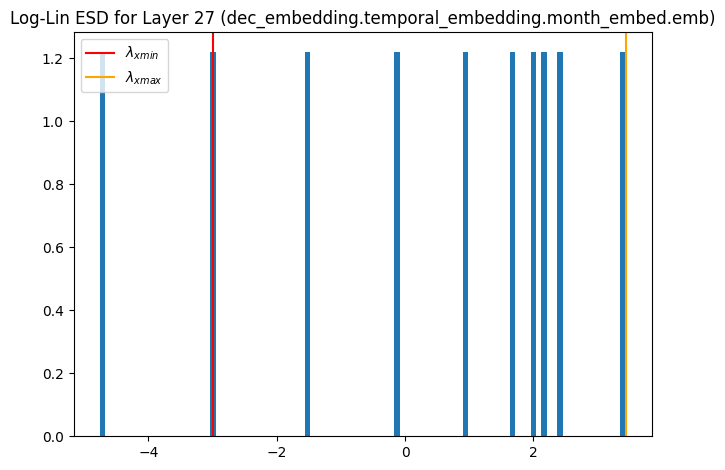

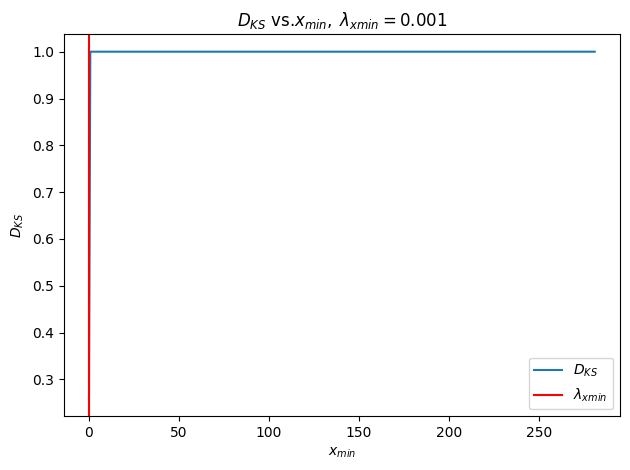

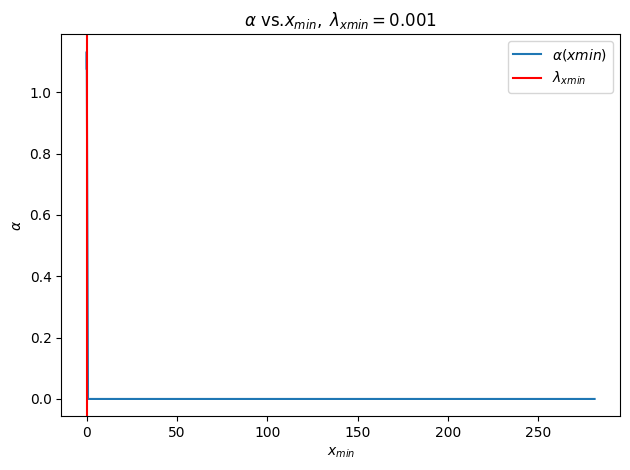

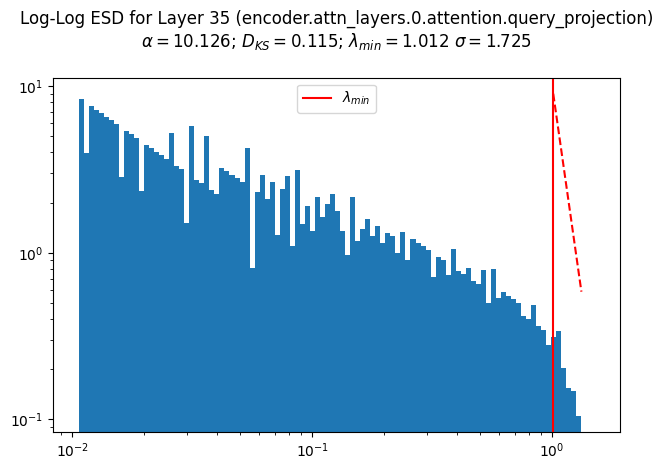

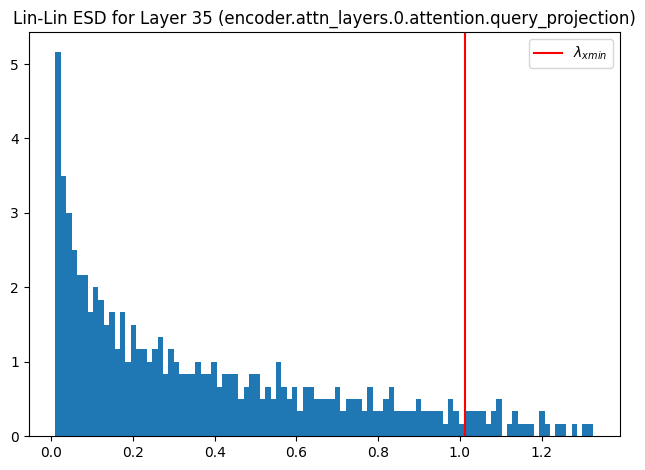

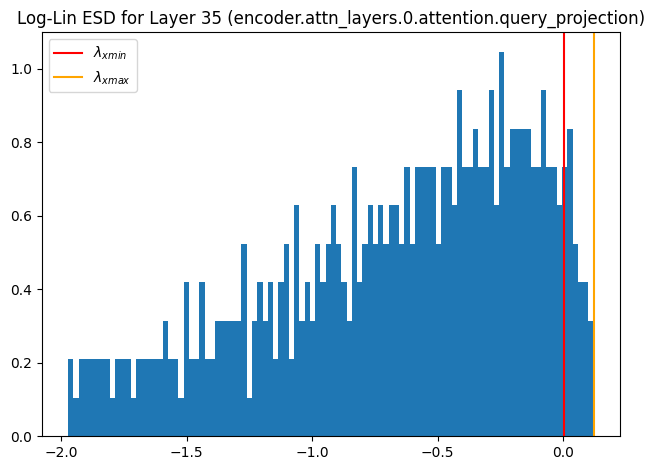

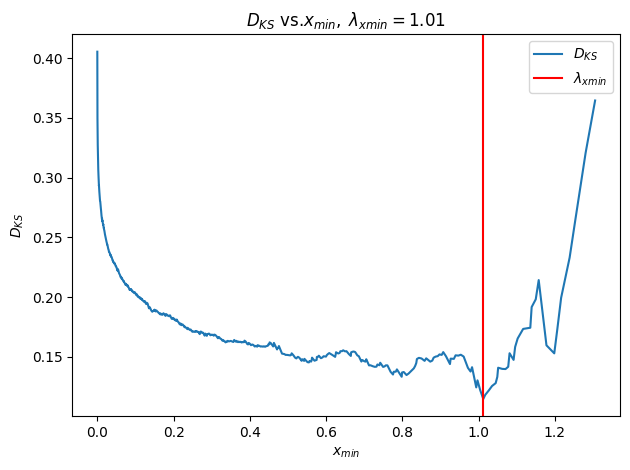

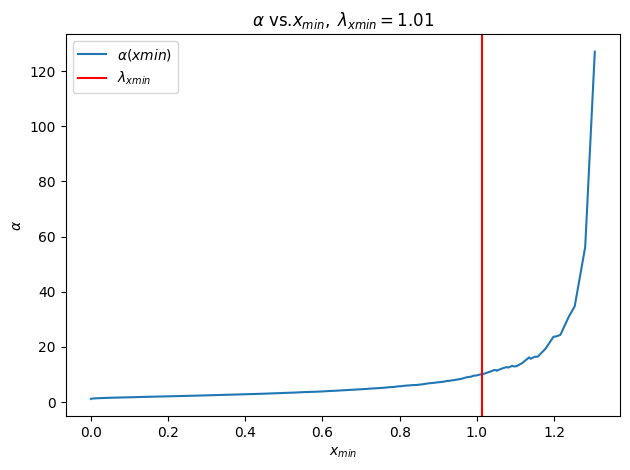

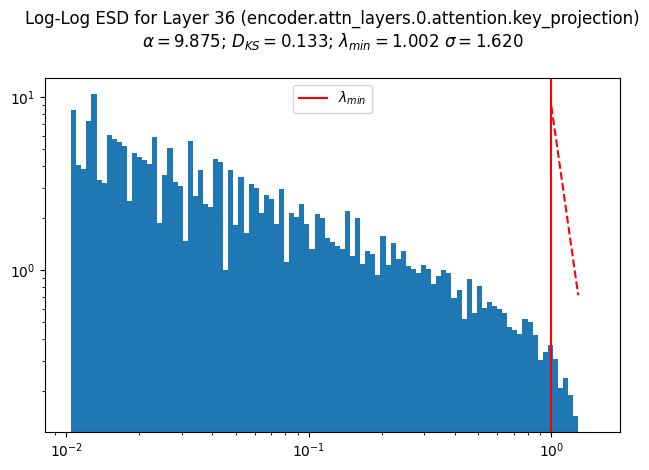

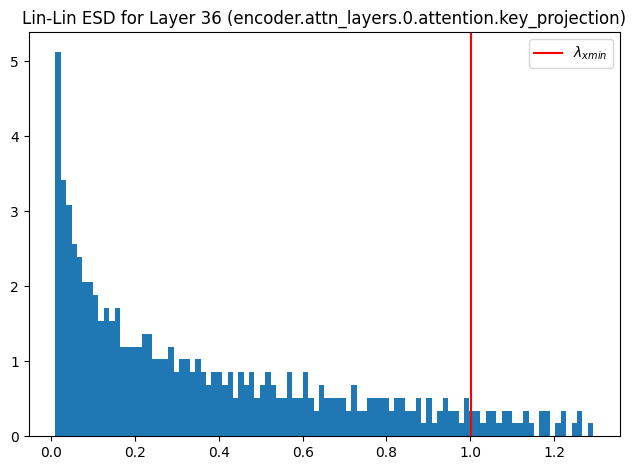

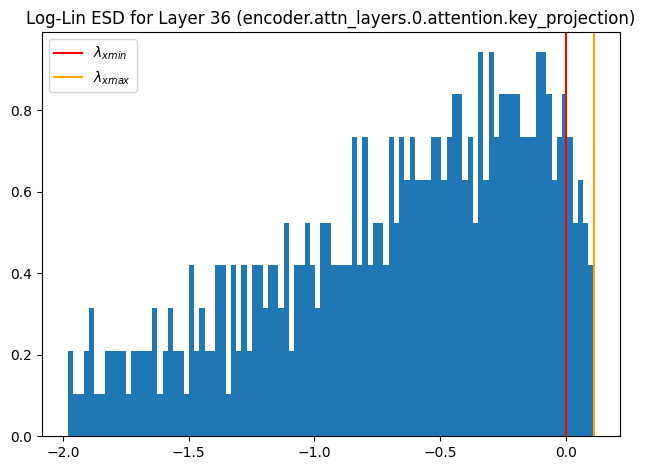

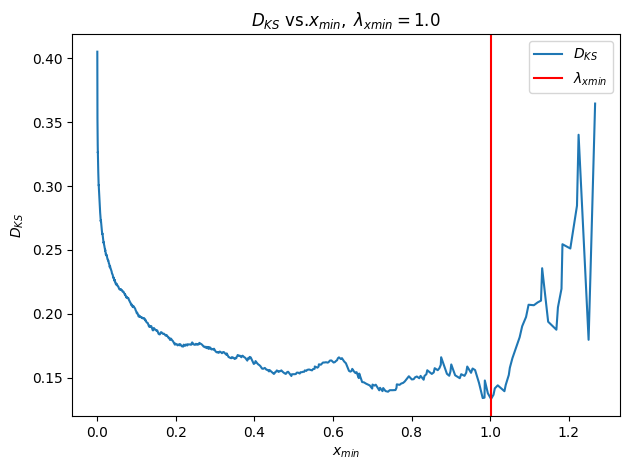

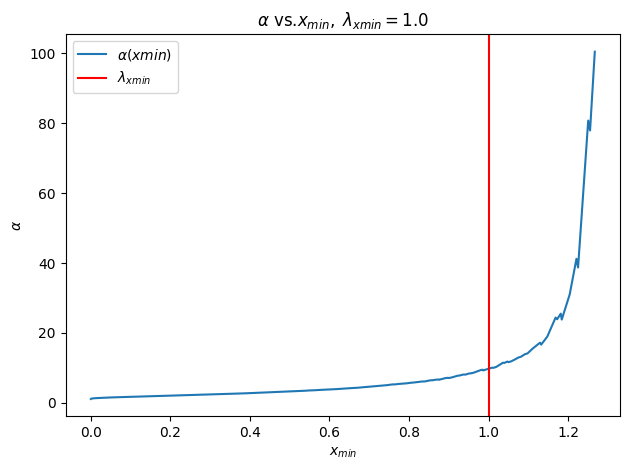

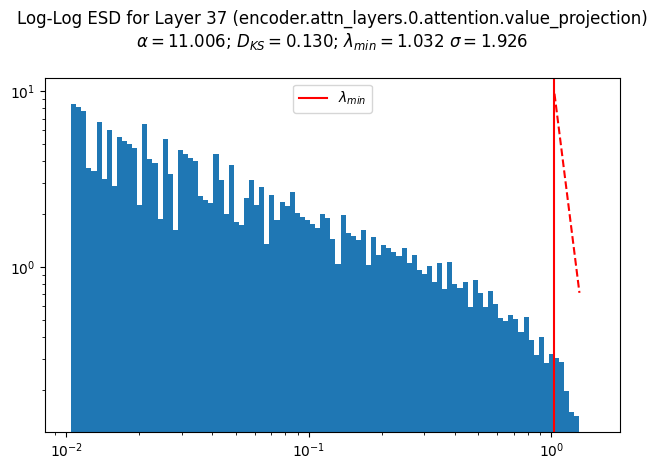

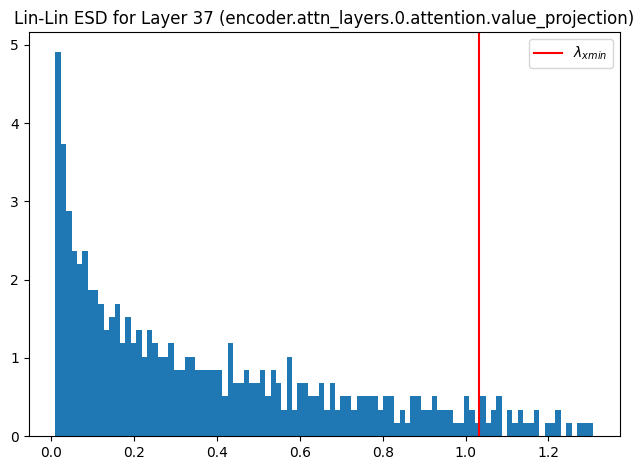

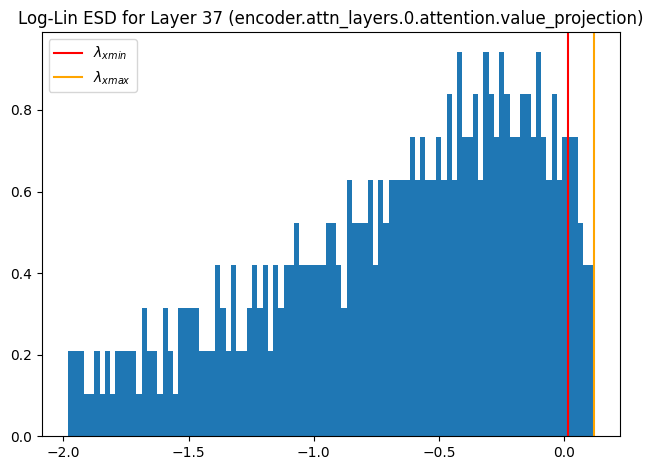

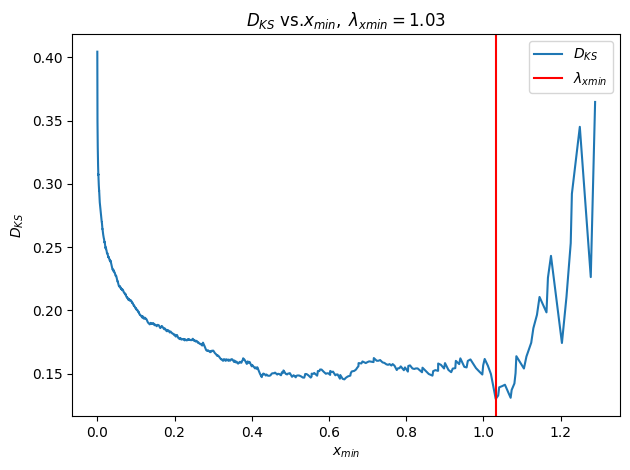

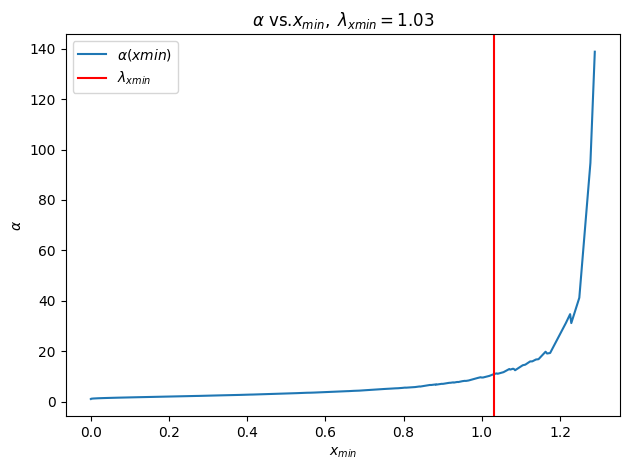

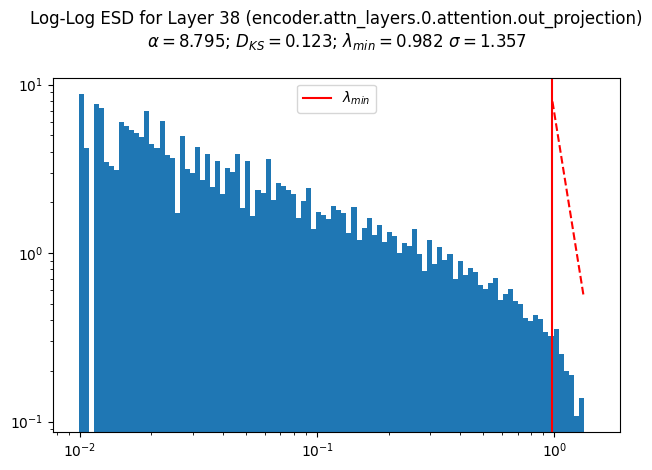

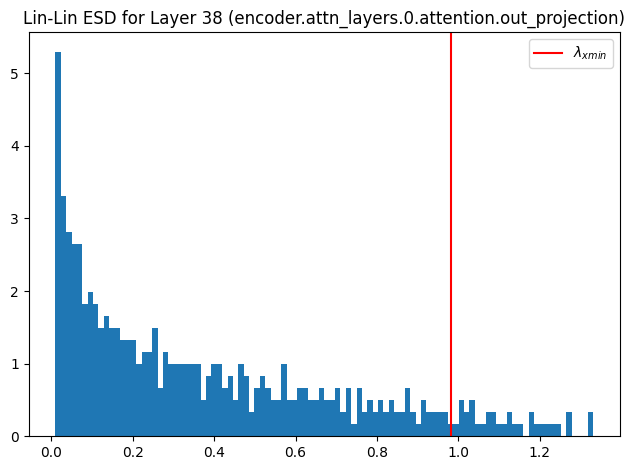

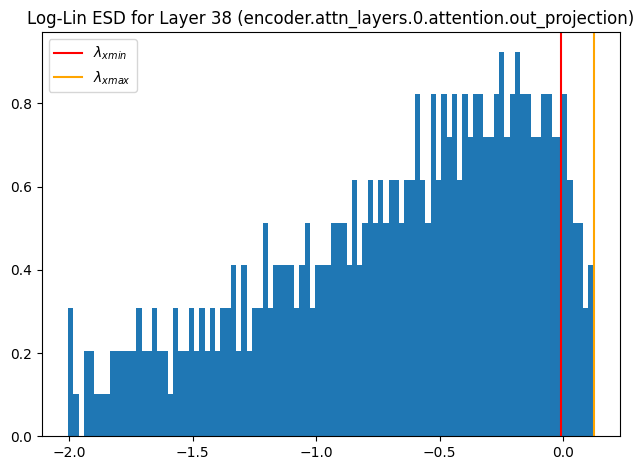

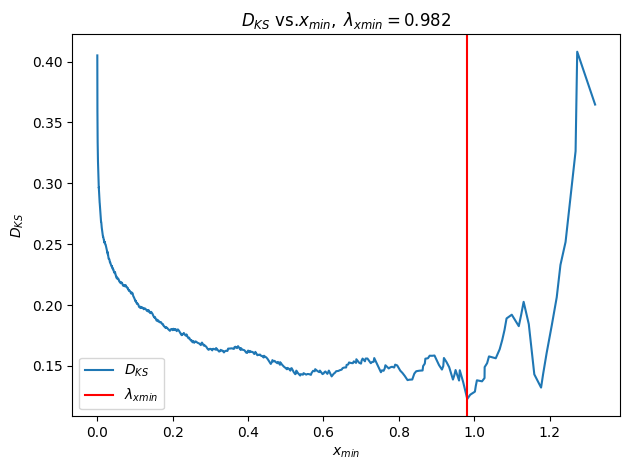

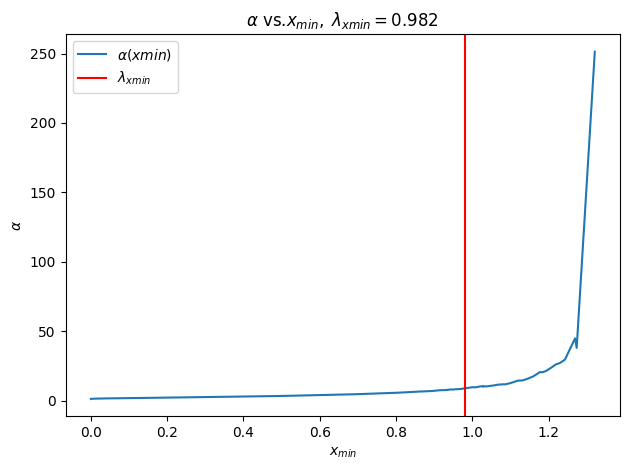

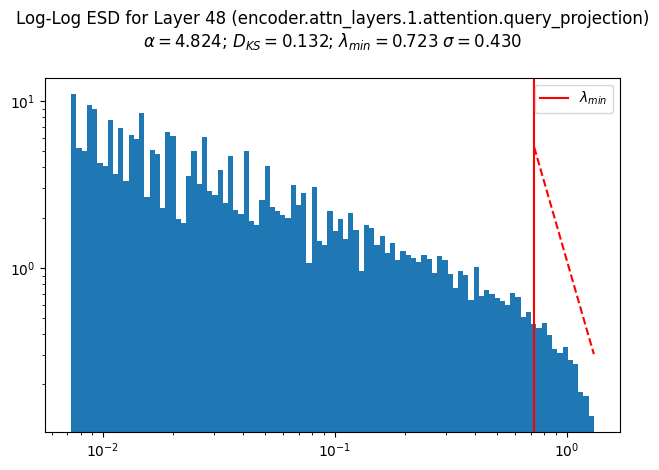

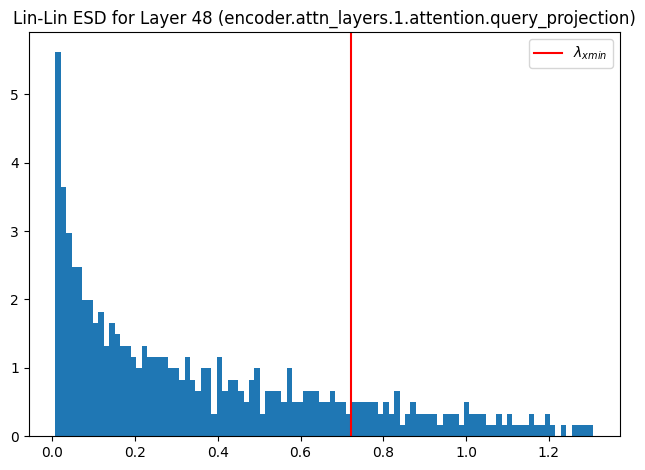

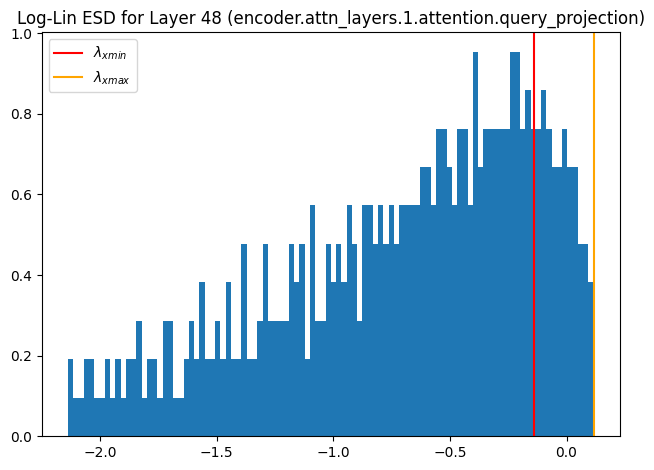

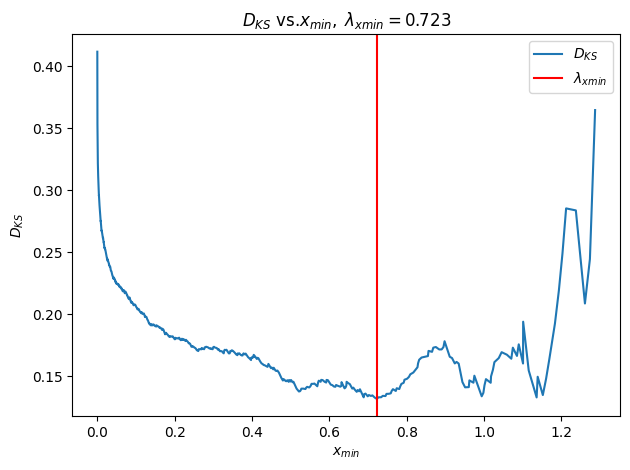

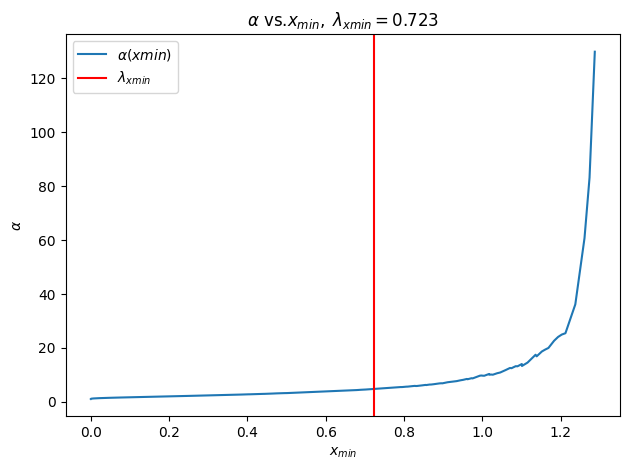

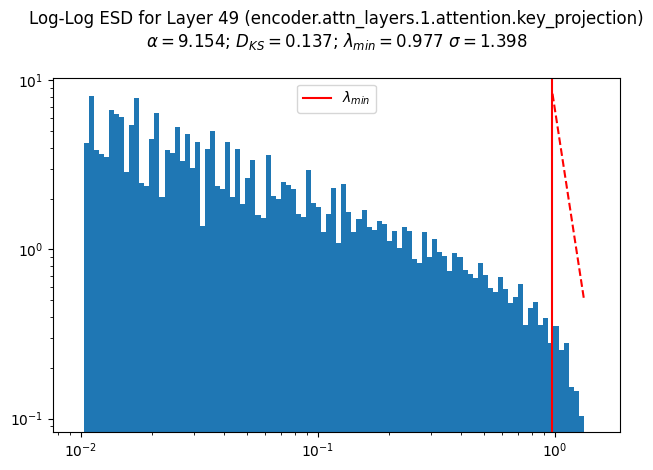

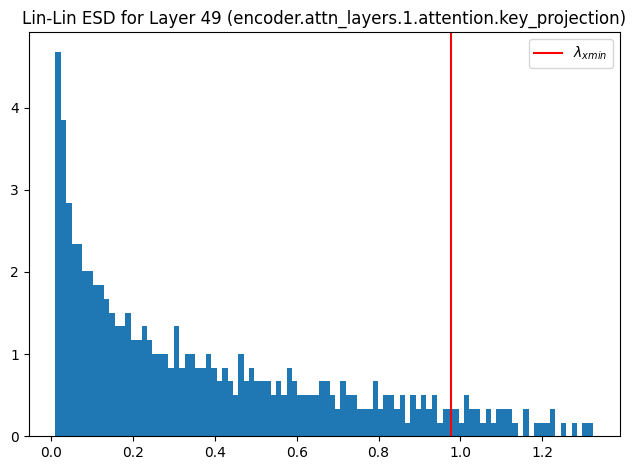

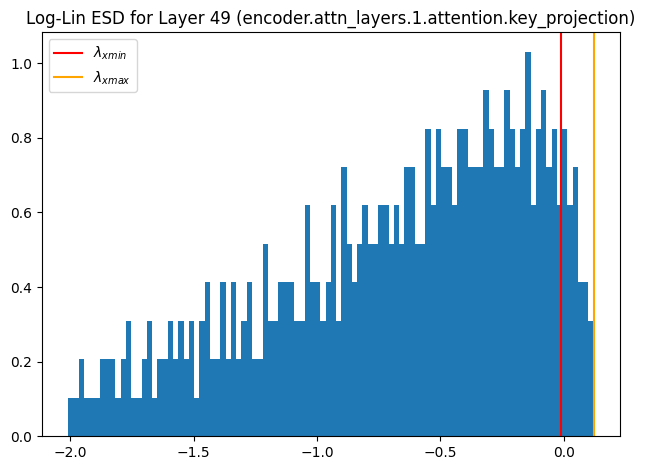

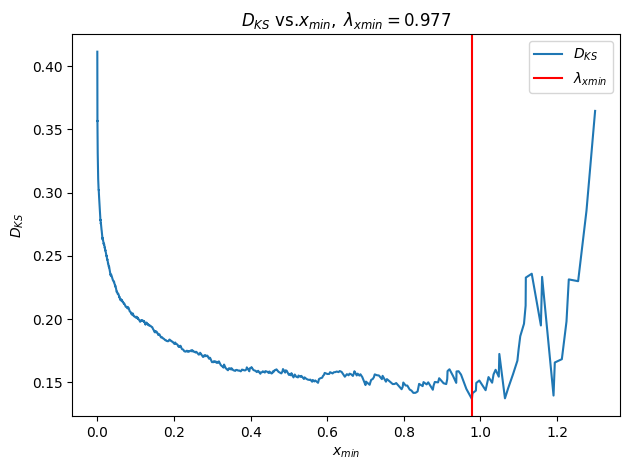

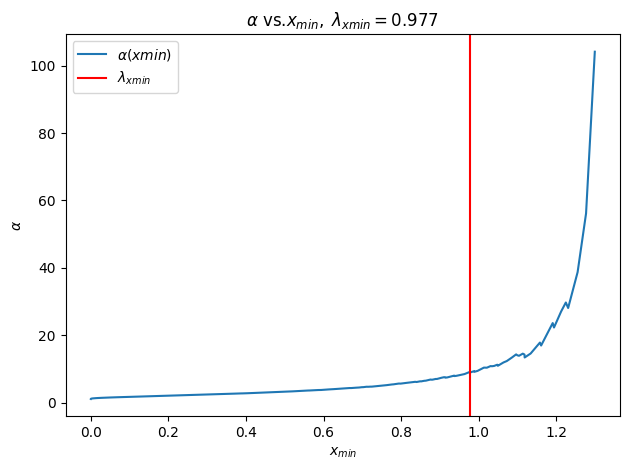

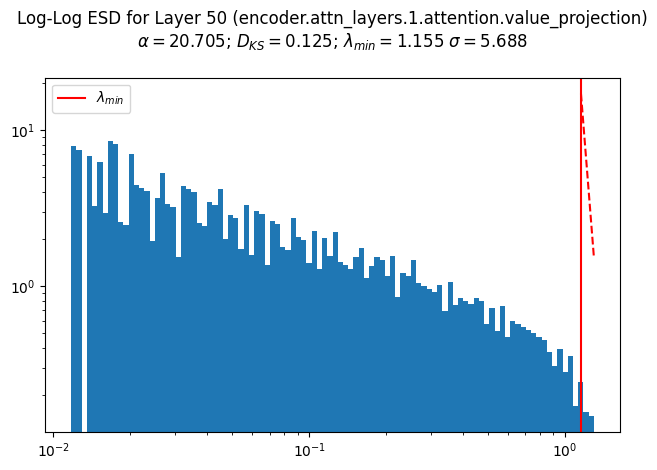

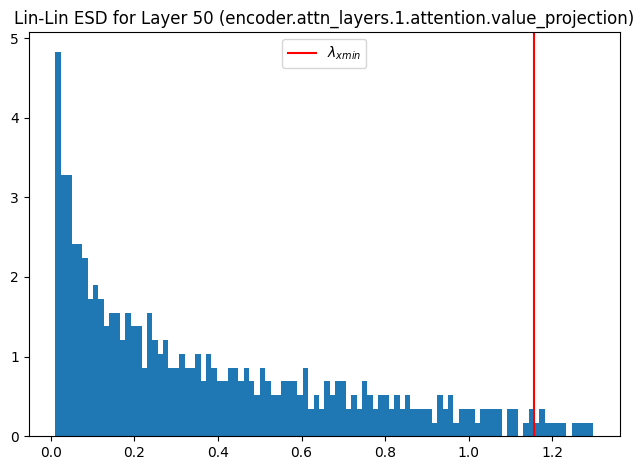

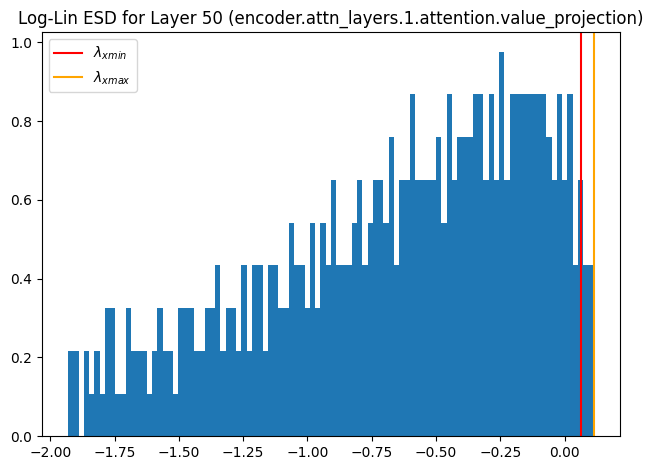

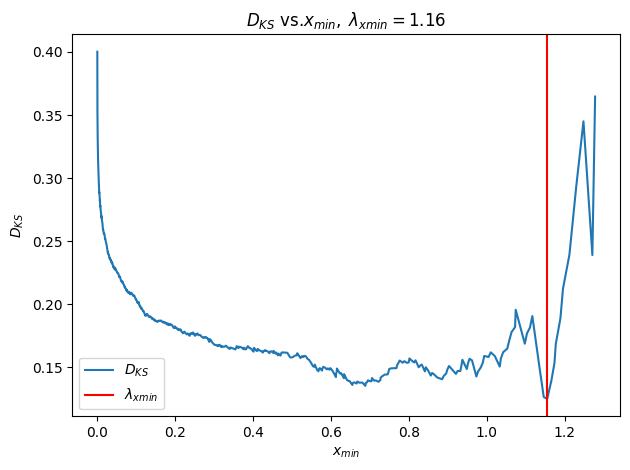

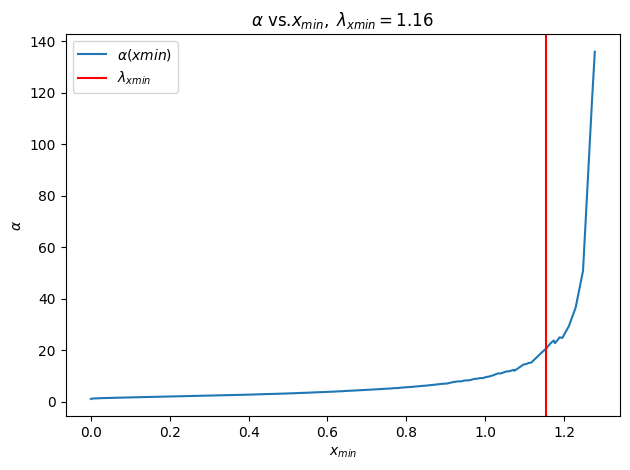

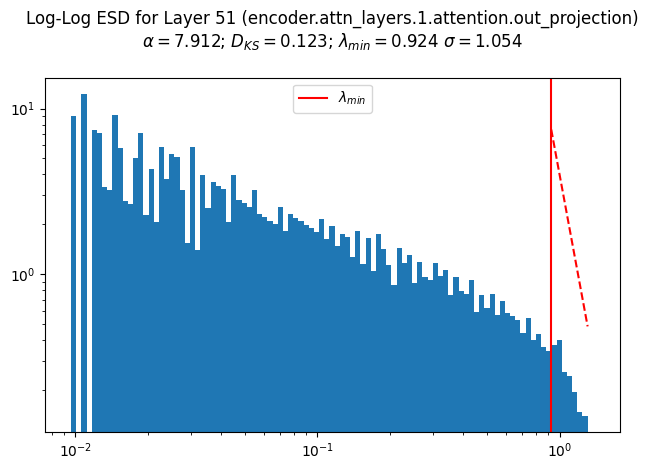

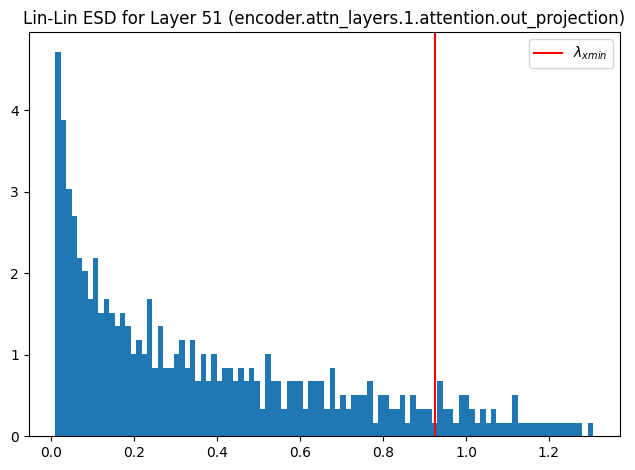

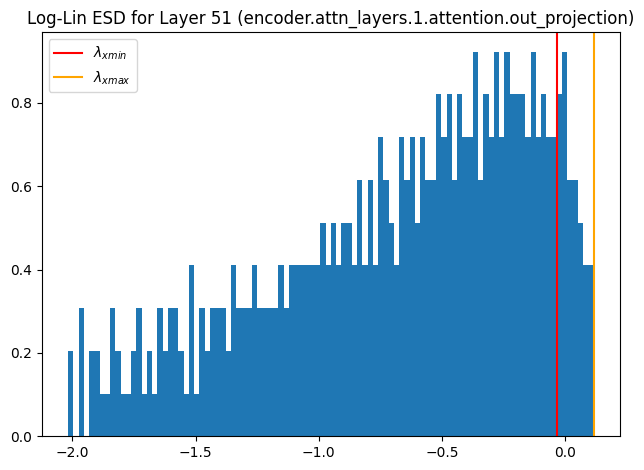

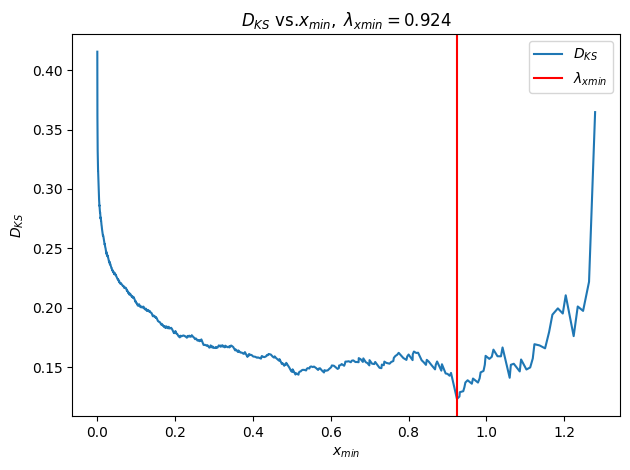

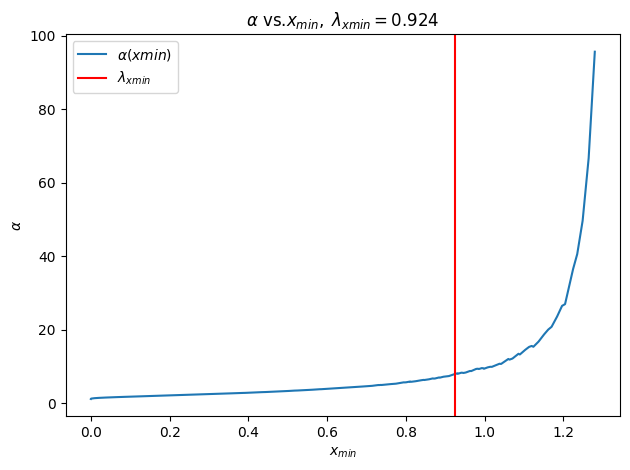

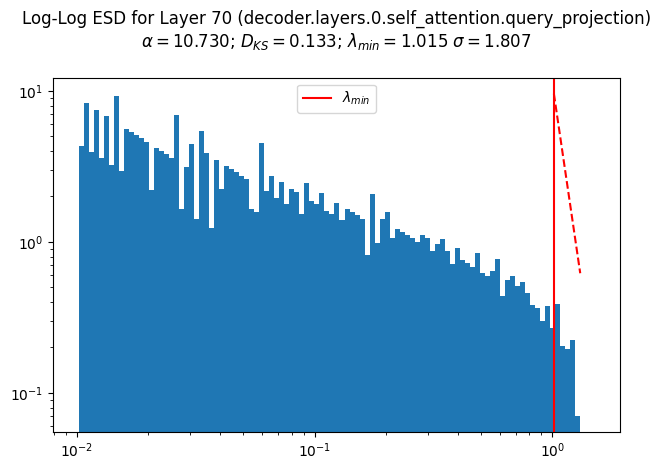

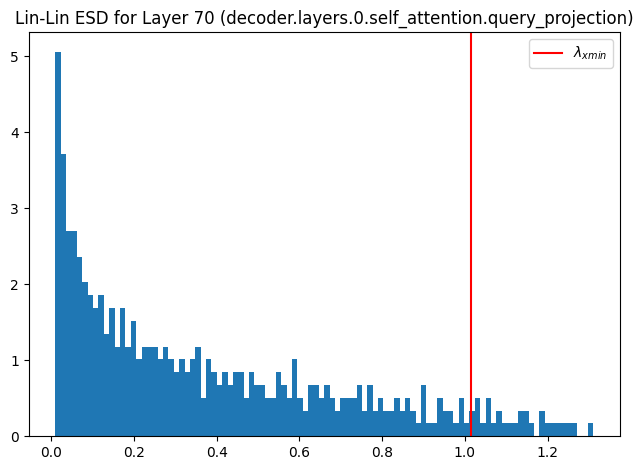

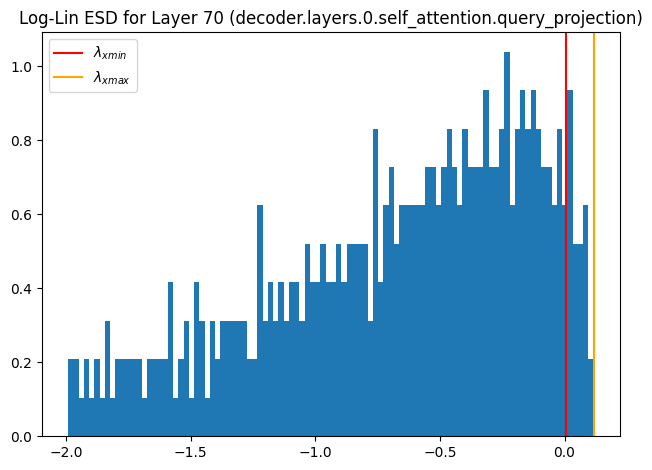

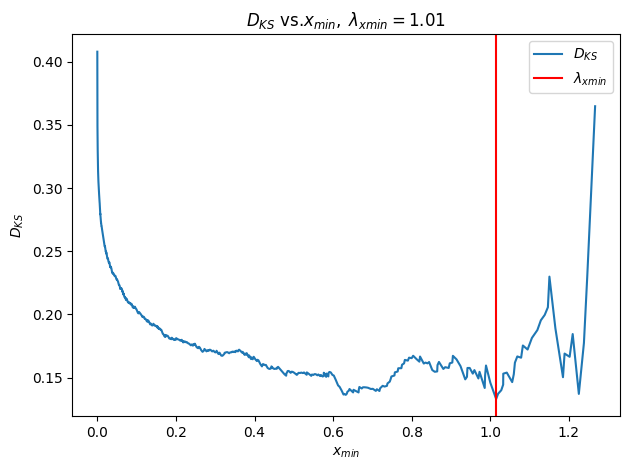

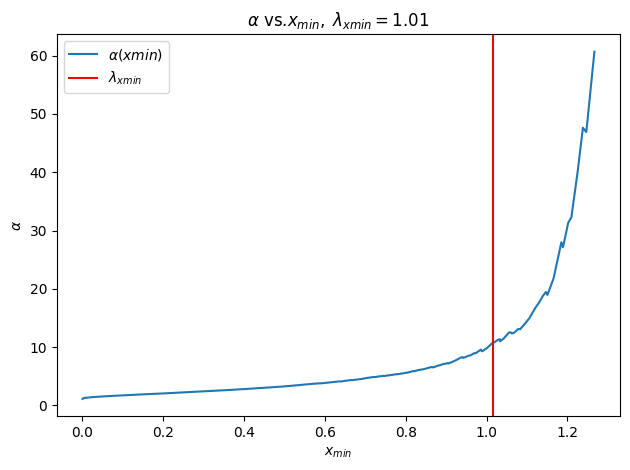

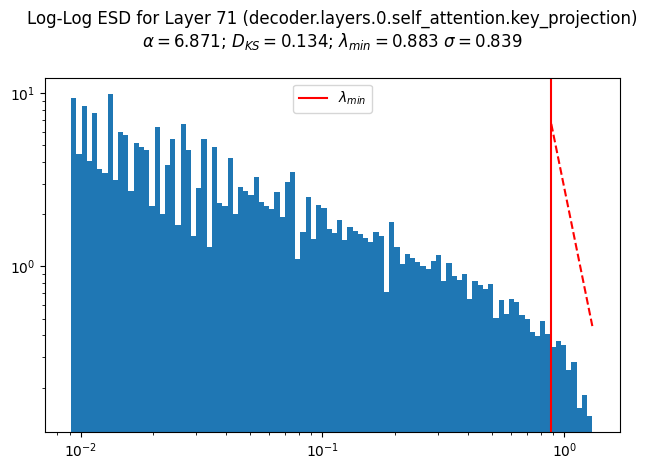

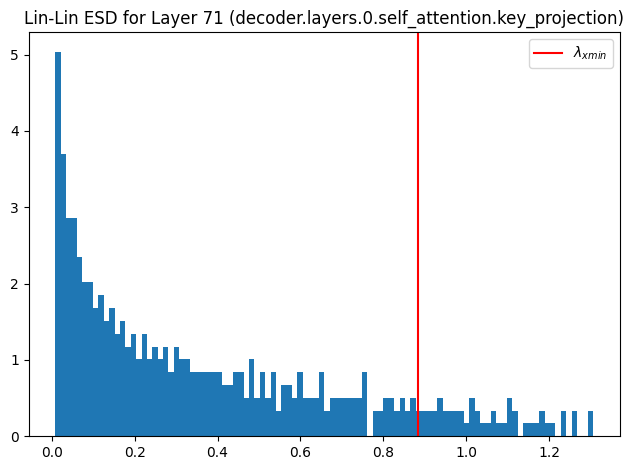

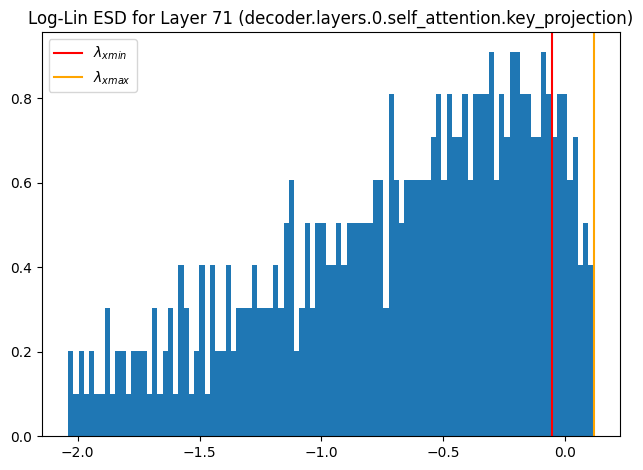

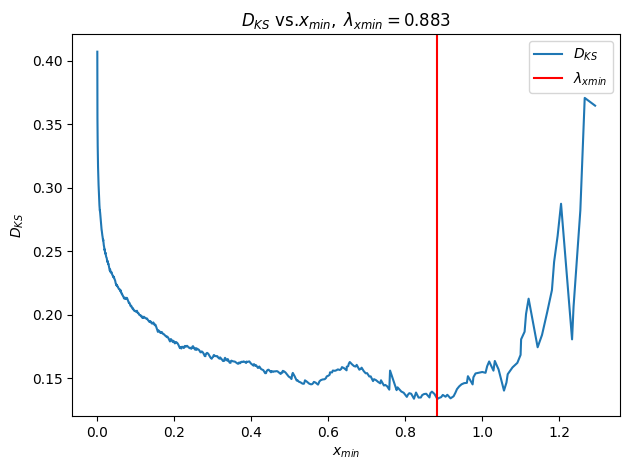

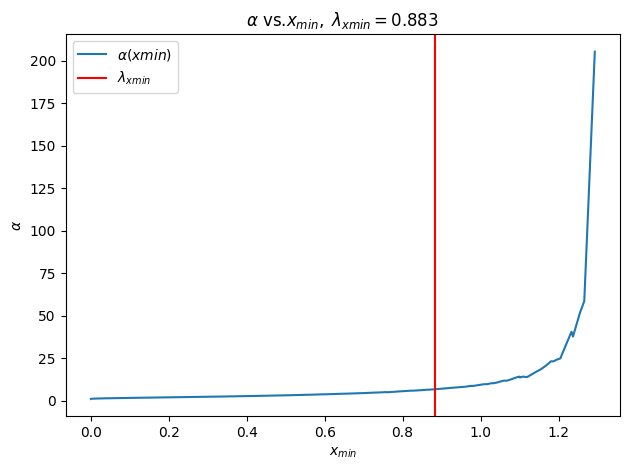

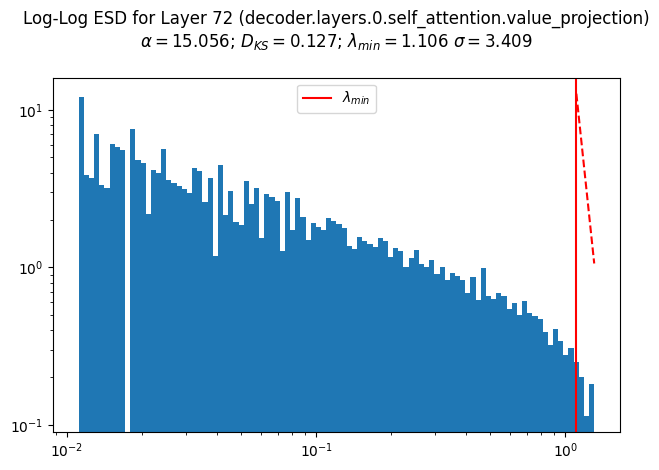

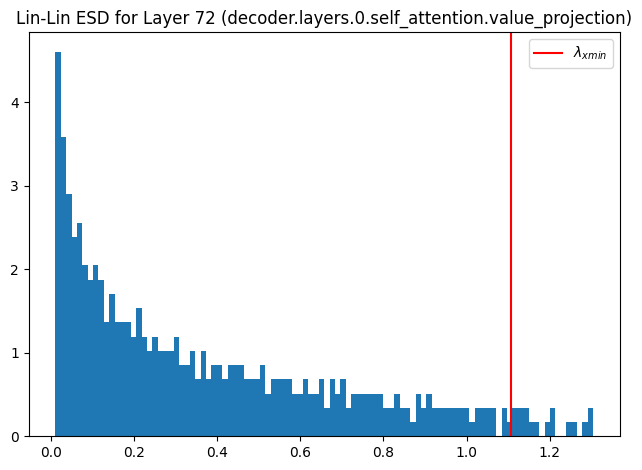

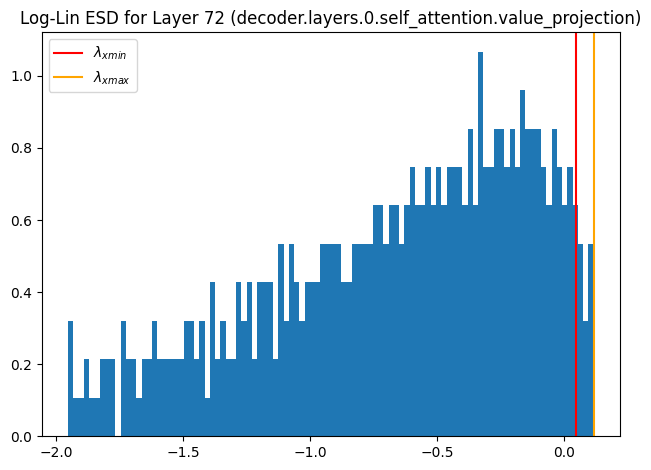

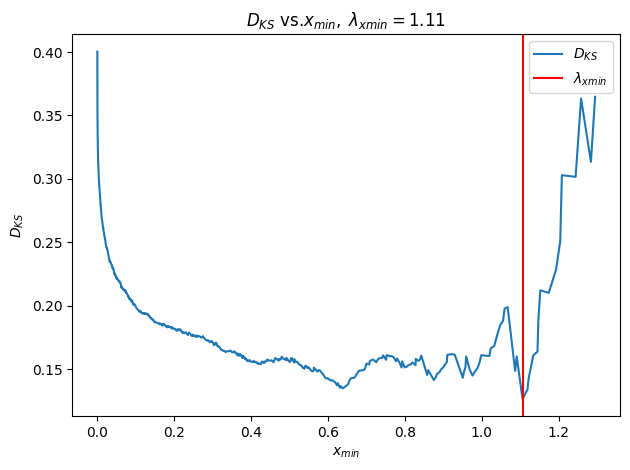

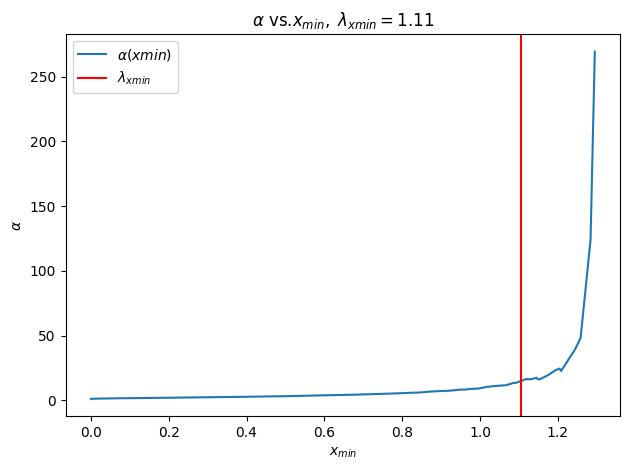

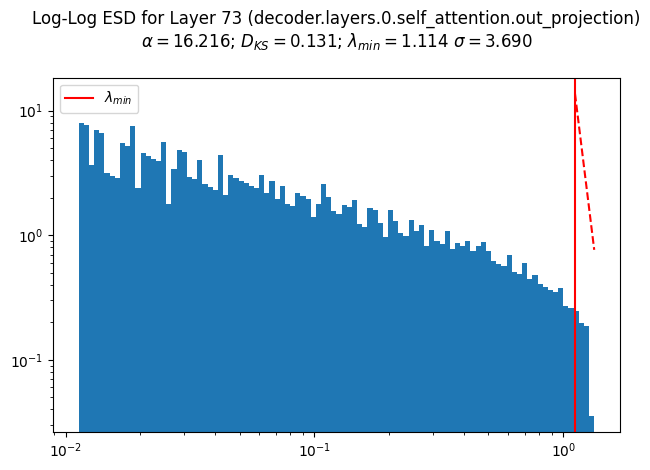

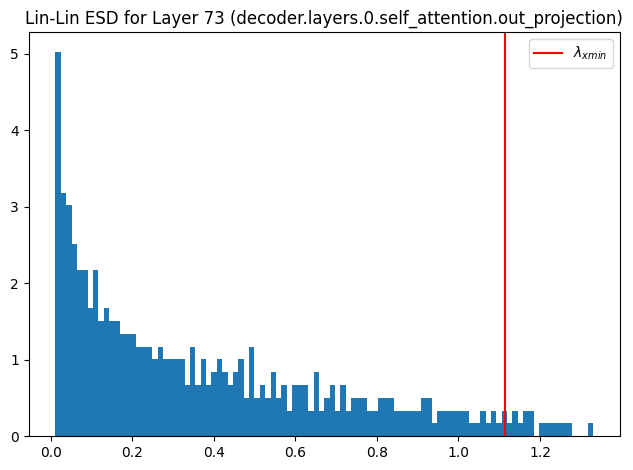

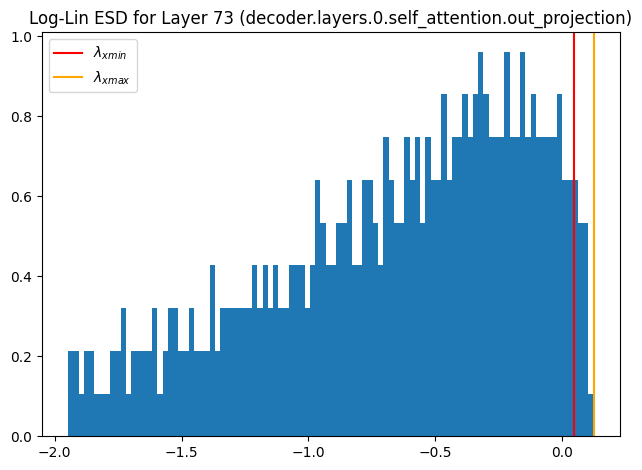

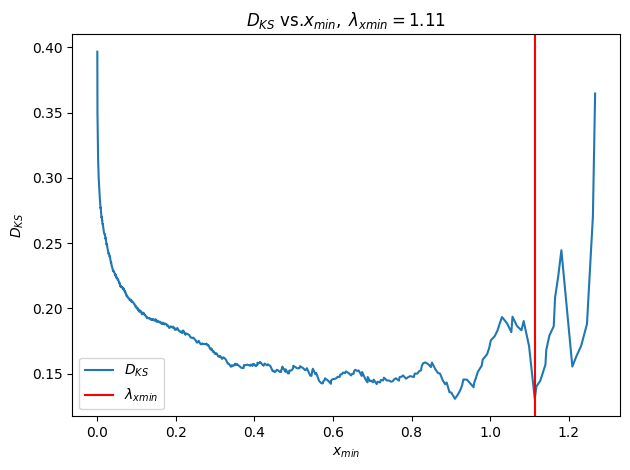

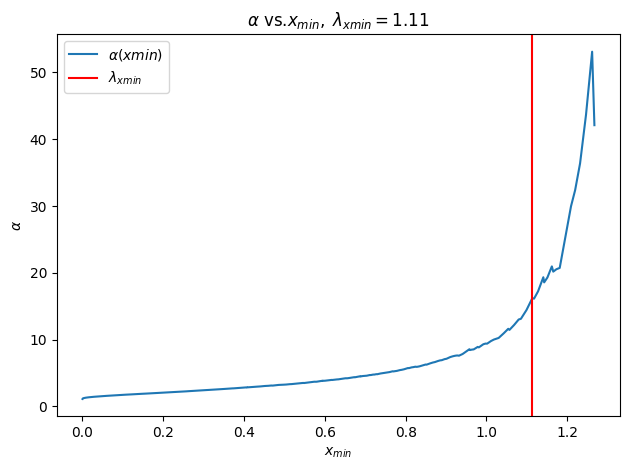

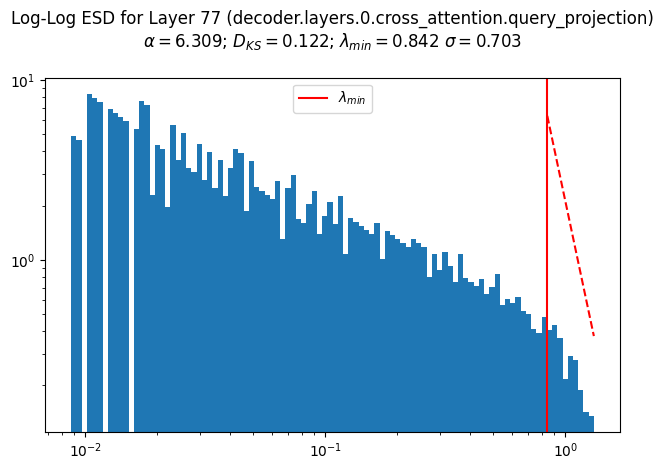

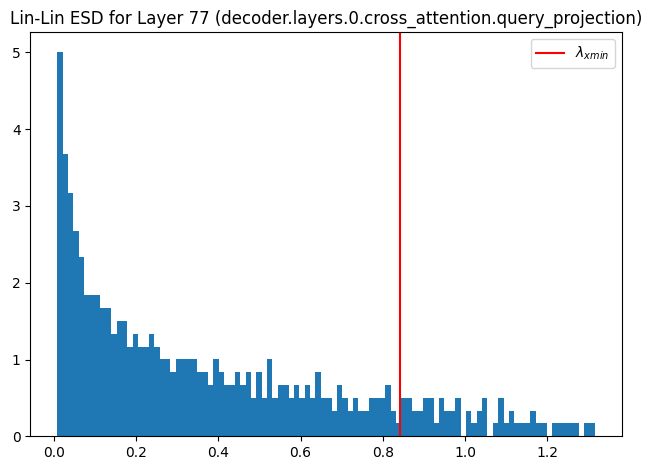

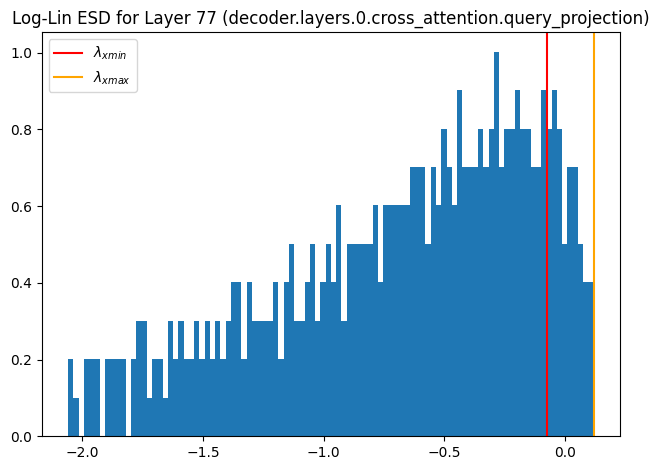

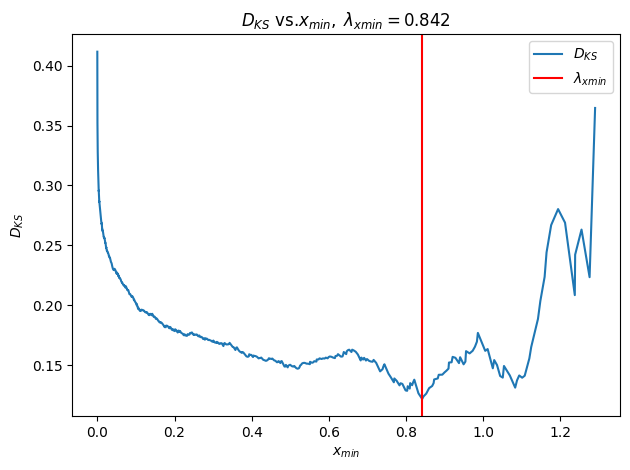

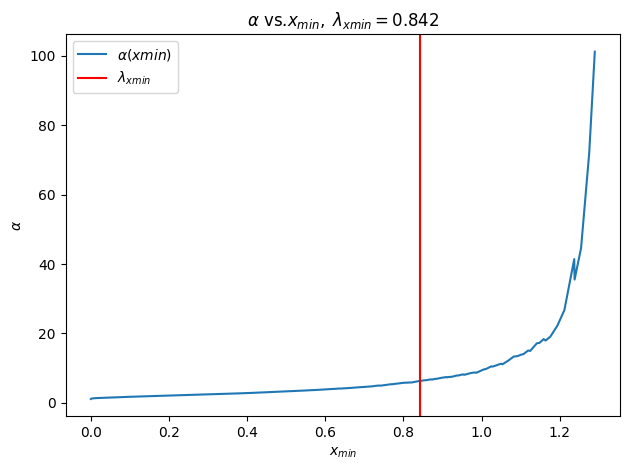

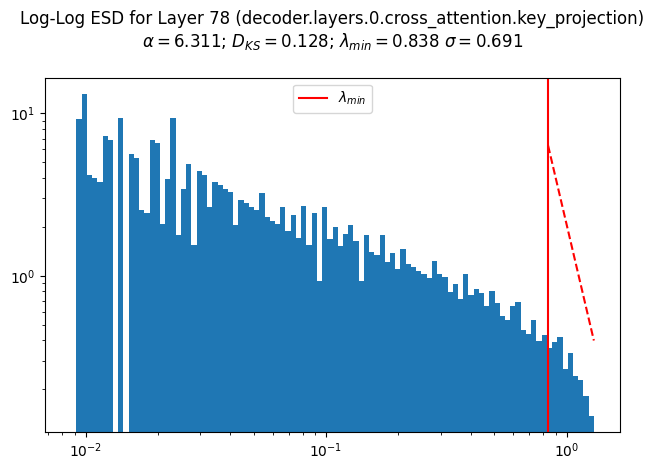

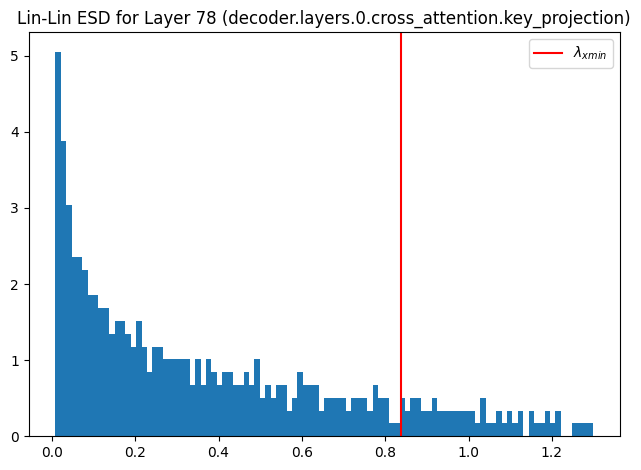

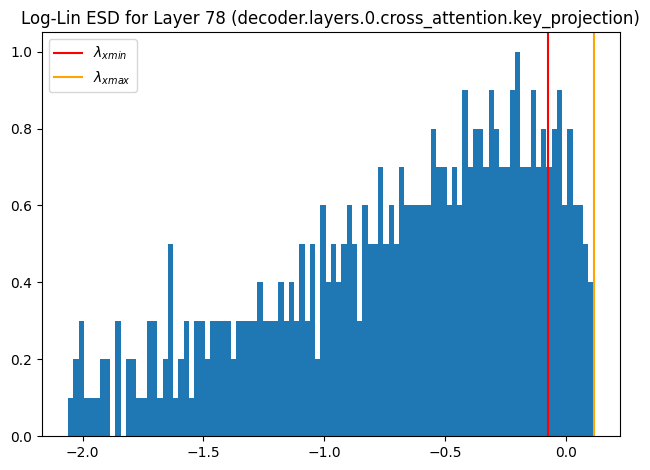

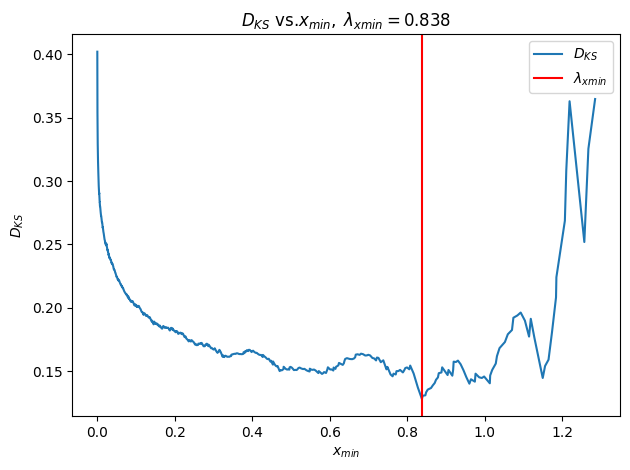

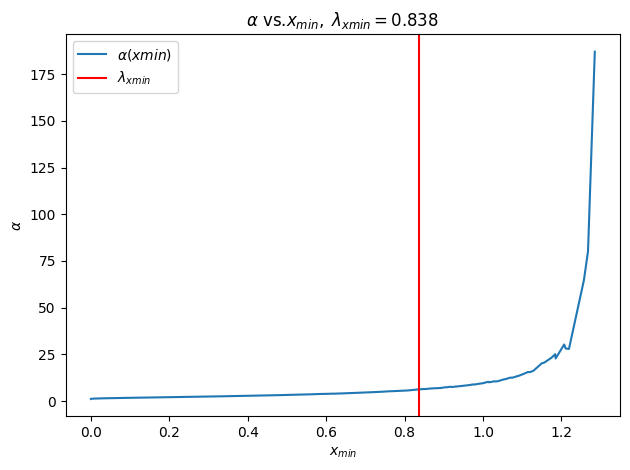

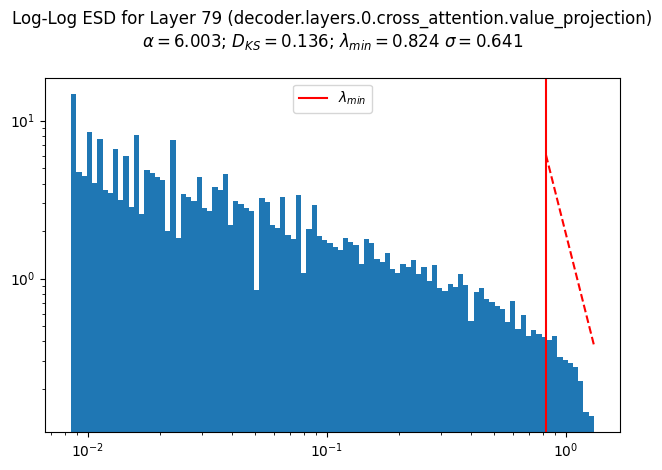

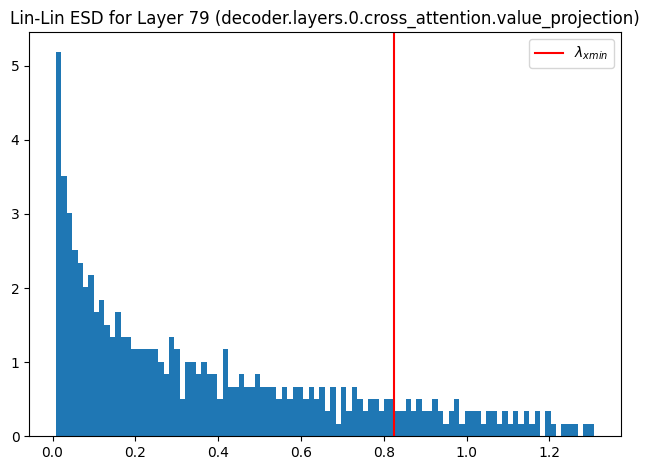

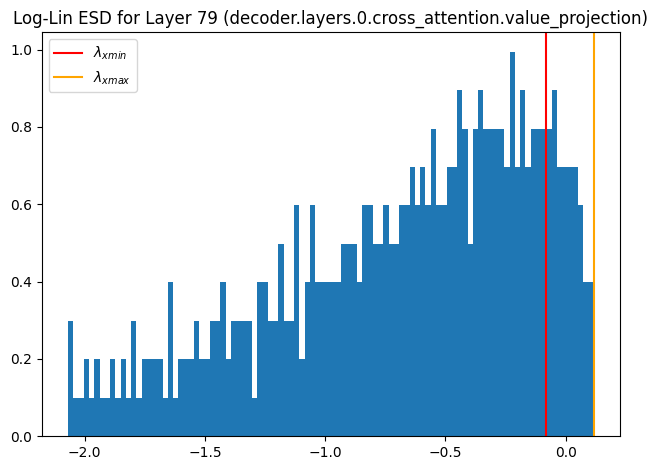

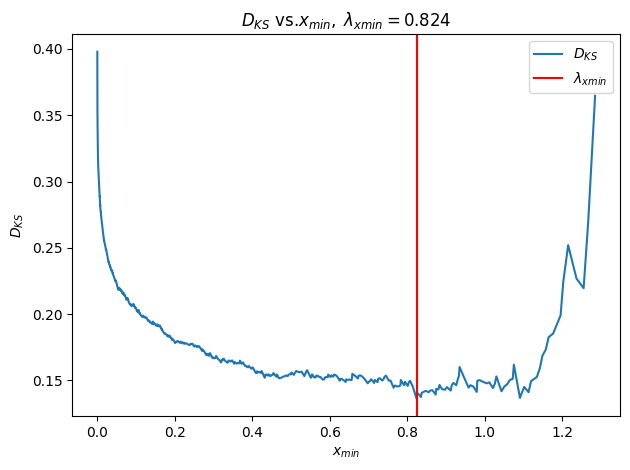

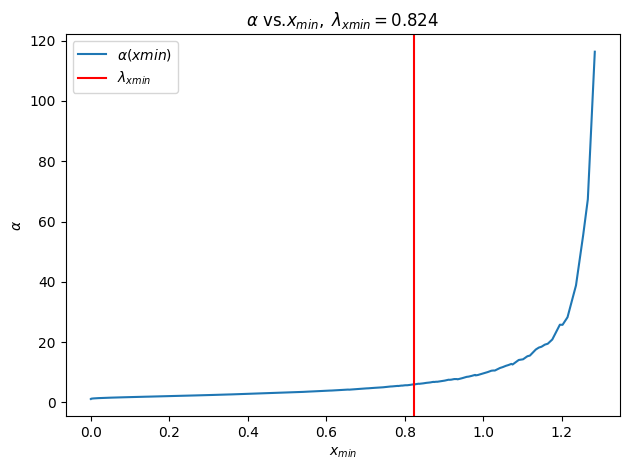

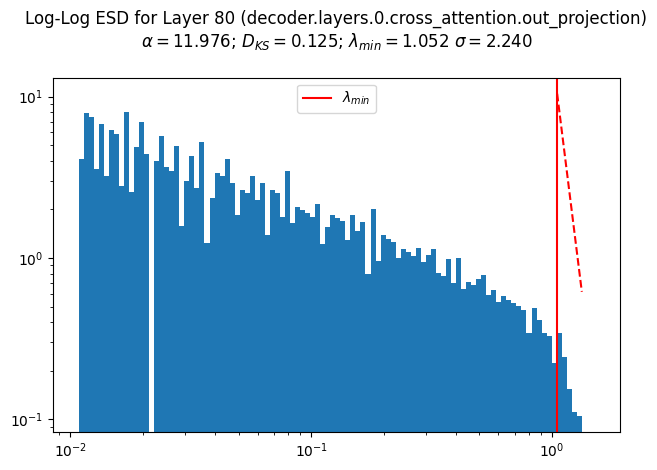

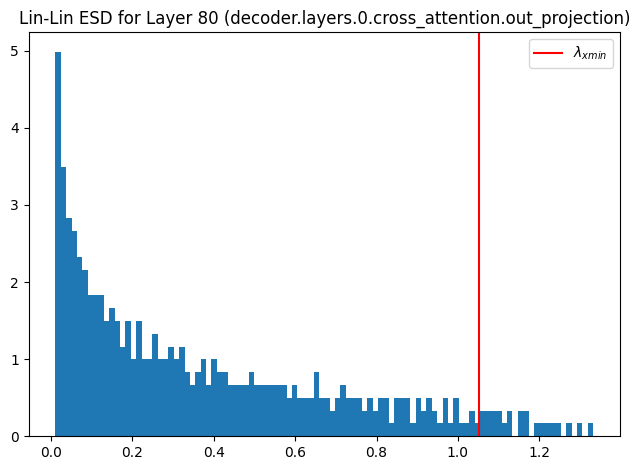

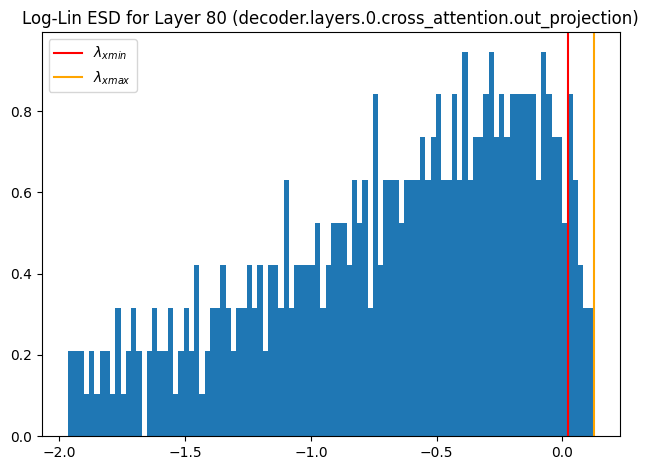

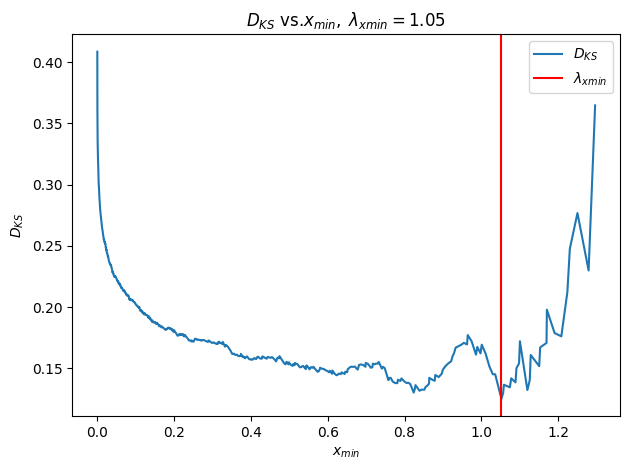

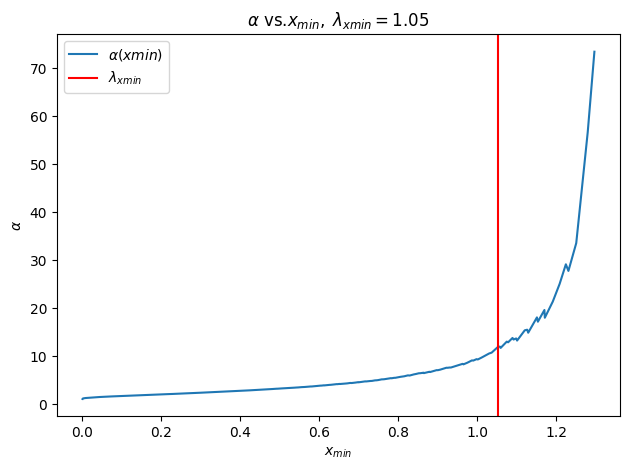

,layer_id,name,alpha,log_norm


<Figure size 640x480 with 0 Axes>

In [4]:
# Load checkpoint if available
checkpoint = Path("../checkpoints/your_trained_checkpoint.pth")
if checkpoint.exists():
    state = torch.load(checkpoint, map_location='cpu')
    if 'model' in state:
        model.load_state_dict(state['model'])
    elif 'state_dict' in state:
        model.load_state_dict(state['state_dict'])
    else:
        model.load_state_dict(state)
    print("Checkpoint loaded.")
else:
    print("Warning: Using random weights.")

model.eval()

# Analyze the full model
watcher = ww.WeightWatcher(model=model)
details = watcher.analyze(plot=True, savefig="esd_encoder_layers.png")
details.to_csv("informer_weightwatcher_details.csv")

# Filter for encoder layers only
if 'layer_type' in details.columns:
    encoder_details = details[details['layer_type'].str.contains('encoder', case=False, na=False)]
else:
    encoder_details = details
encoder_details.to_csv("informer_encoder_details.csv")

# Show only columns that exist
cols = [c for c in ['layer_id', 'name', 'alpha', 'log_norm', 'log_alpha', 'summary'] if c in encoder_details.columns]
display(encoder_details[cols] if cols else encoder_details)

Encoder layer singular values:


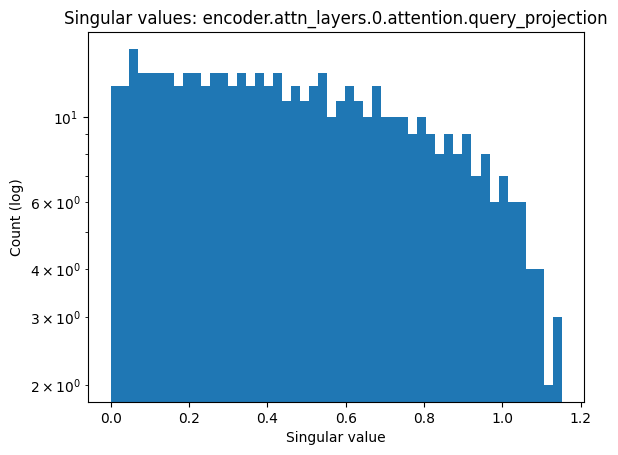

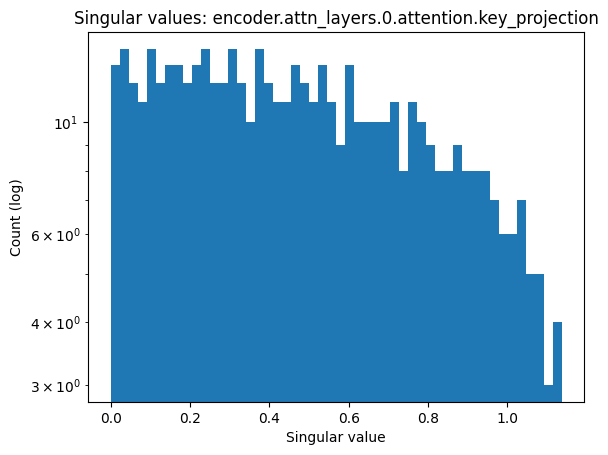

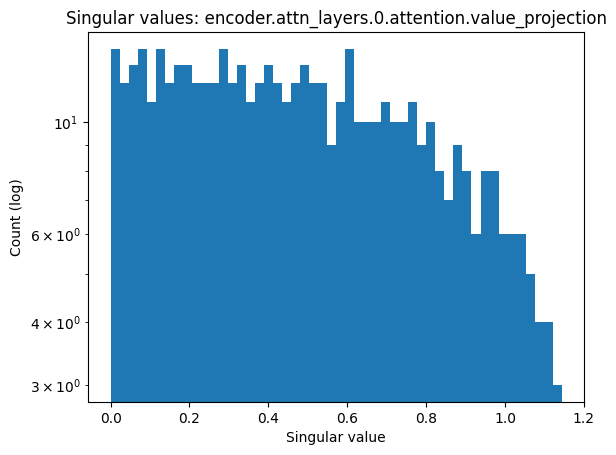

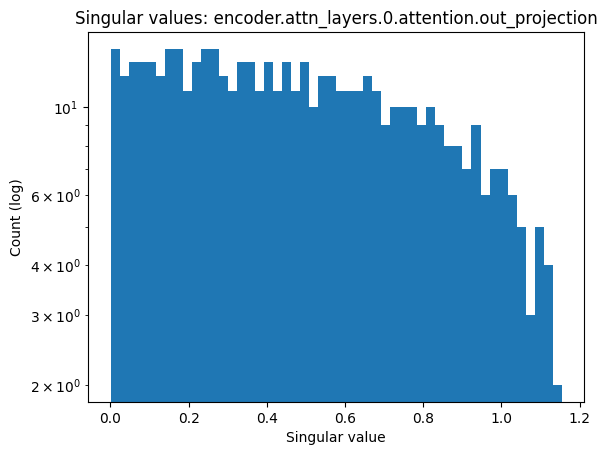

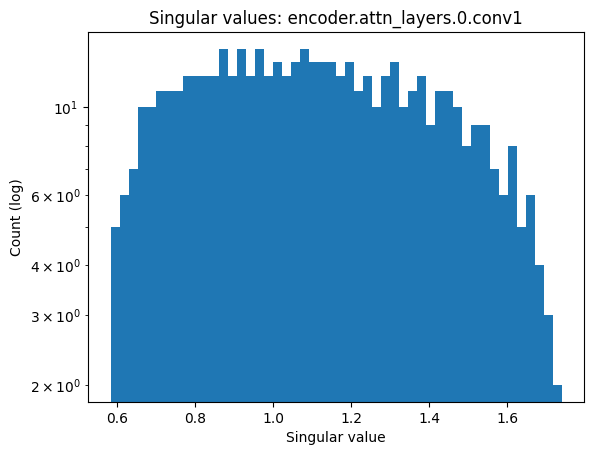

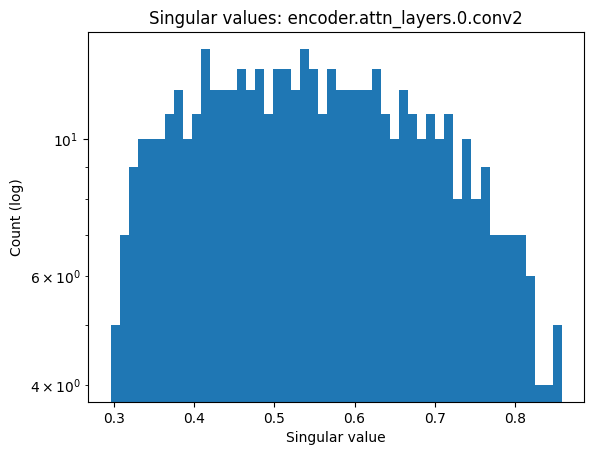

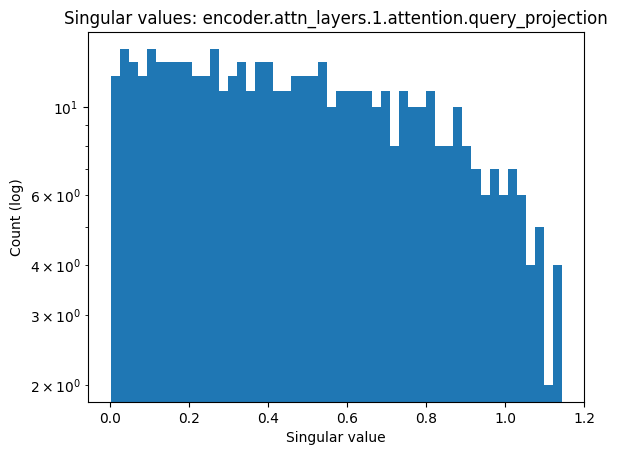

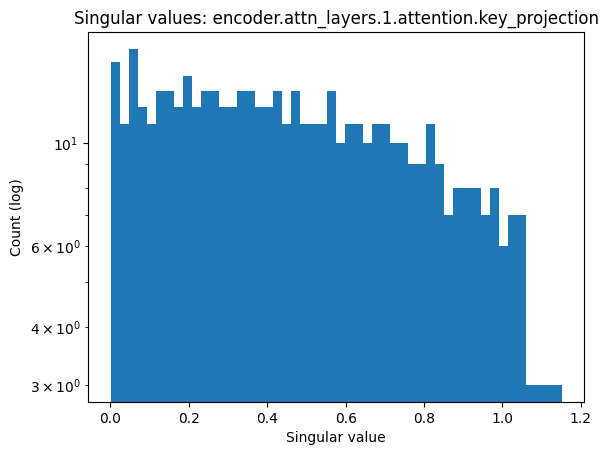

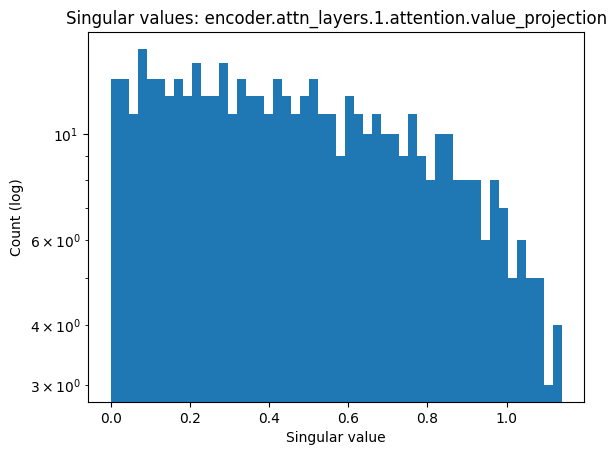

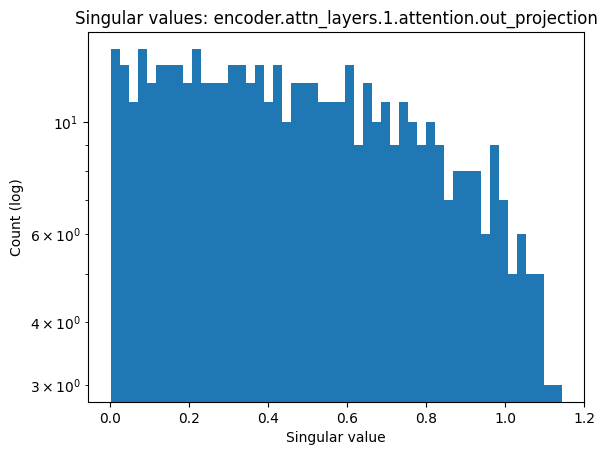

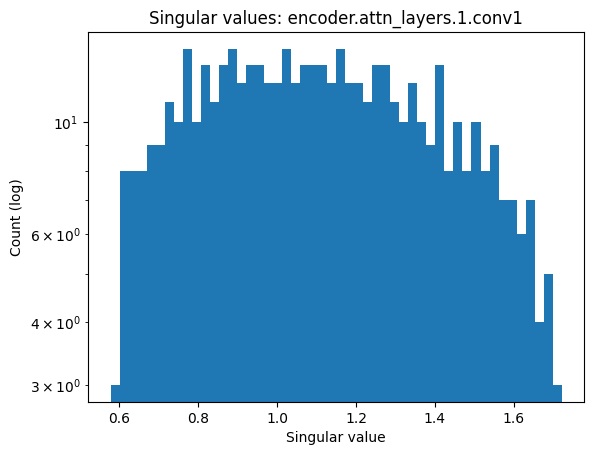

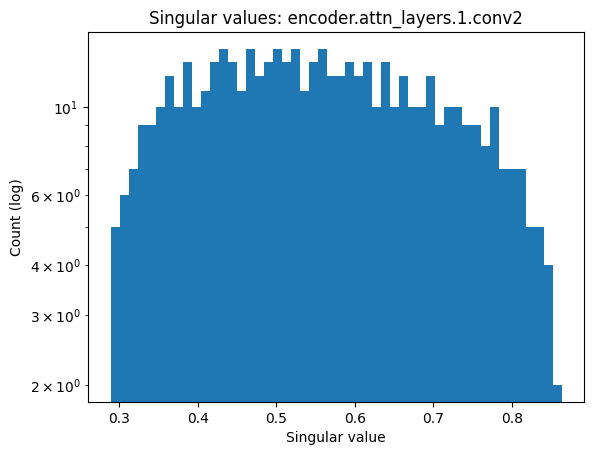

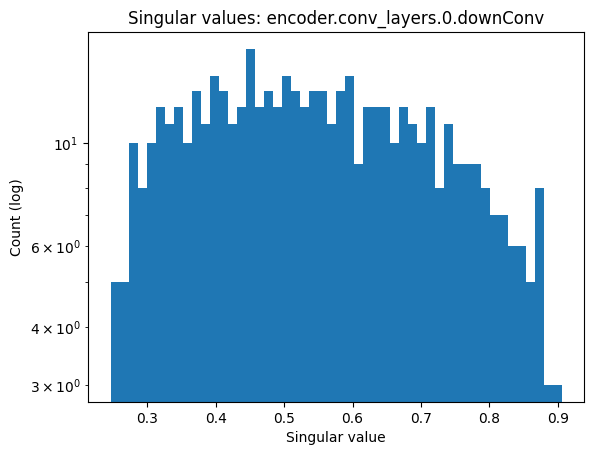

In [ ]:
# Extract and plot singular values for each encoder submodule
def collect_encoder_weights(module, prefix=""):
    for name, child in module.named_children():
        if isinstance(child, (torch.nn.Linear, torch.nn.Conv1d)):
            w = child.weight.detach().cpu()
            if w.ndim > 2:
                w = w.reshape(w.shape[0], -1)
            s = torch.linalg.svdvals(w).numpy()
            plt.figure()
            plt.hist(s, bins=50, log=True)
            plt.title(f"Singular values: {prefix}.{name}")
            plt.xlabel("Singular value")
            plt.ylabel("Count (log)")
            plt.show()
        collect_encoder_weights(child, f"{prefix}.{name}")

print("Encoder layer singular values:")
collect_encoder_weights(model.encoder, "encoder")